# DAPPC – LAB 1
## Hierarchical Clustering-based Missing Value Imputation

In this notebook you will:

1. Load a prepared dataset  
2. Explore missing values  
3. Apply Hierarchical Clustering-based imputation  
5. Save the imputed dataset

We assume:
- The dataset is already cleaned (columns/rows filtered)
- Outcome has 3 classes (0,1,2)

## 0) Setup


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

## 1) Load Dataset


In [5]:
from pathlib import Path

if Path("/content").exists():
    file_path = "/content/Dataset_DAPPC_2026.xlsx"
else:
    for candidate in (Path("Dataset_DAPPC_2026.xlsx"), Path("LAB1/Dataset_DAPPC_2026.xlsx")):
        if candidate.exists():
            file_path = str(candidate)
            break
    else:
        file_path = "Dataset_DAPPC_2026.xlsx"
available_sheets = pd.ExcelFile(file_path).sheet_names
sheet_name = next((name for name in ("Dataset_v1", "Dataset") if name in available_sheets), available_sheets[0])
print("Using sheet:", sheet_name)

df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Initial shape:", df.shape)
df.head()

Using sheet: Dataset_v1
Initial shape: (3893, 76)


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,gender,age,weight,charlson_comorbidity_index,...,first_plateau_pressure,std_plateau_pressure,vent_duration_hours,outcome,comorb_total,comorb_catcardiac_cardiovascular,comorb_catrespiratory_pulmonary,comorb_catmetabolic_endocrine_renal,comorb_catneurological_neuromuscular_psychiatric,comorb_catsystemic_immune_oncologic
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,1,66,113.3,3,...,19.0,1.909727,96.0,2,1,0,0,1,0,0
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,1,53,106.7,5,...,10.0,8.337289,230.0,1,5,0,1,1,0,0
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,0,66,46.1,6,...,17.0,1.224745,34.0,1,4,0,0,1,0,0
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,1,49,106.0,1,...,11.0,4.877563,399.0,2,4,1,0,1,1,0
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,0,77,49.3,7,...,17.0,3.239768,155.0,2,4,1,0,1,0,1


## 2) Column Index Table


In [6]:
import numpy as np

if 'outcome' in df.columns:
    outcome_col = df.pop('outcome')
    df['outcome'] = outcome_col

display(pd.DataFrame({
    "index": np.arange(df.shape[1]),
    "column_name": df.columns,
    "dtype": df.dtypes
}))

,index,column_name,dtype
subject_id,0,subject_id,int64
hadm_id,1,hadm_id,int64
stay_id,2,stay_id,int64
ICU,3,ICU,int64
ICU_intime,4,ICU_intime,str
...,...,...,...
comorb_catrespiratory_pulmonary,71,comorb_catrespiratory_pulmonary,int64
comorb_catmetabolic_endocrine_renal,72,comorb_catmetabolic_endocrine_renal,int64
comorb_catneurological_neuromuscular_psychiatric,73,comorb_catneurological_neuromuscular_psychiatric,int64
comorb_catsystemic_immune_oncologic,74,comorb_catsystemic_immune_oncologic,int64


## 3) Explore Missing Values

In [7]:
# Total missing values (global)
print("Total missing values:", df.isna().sum().sum())

# Missing per column: count + percentage
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2)
})

# Display only columns with at least one missing value
missing_table = missing_table[missing_table["missing_count"] > 0] \
                    .sort_values("missing_%", ascending=False)

display(missing_table)

Total missing values: 906


,missing_count,missing_%
weight,177,4.55
std_plateau_pressure,140,3.60
first_plateau_pressure,137,3.52
first_temperature,58,1.49
first_PTT,57,1.46
std_PTT,57,1.46
std_PT,54,1.39
first_PT,53,1.36
std_temperature,53,1.36
std_PEEP,34,0.87


## 4) Apply Hierarchical clustering-based Imputation

Adopting hierarchical clustering as MVs imputations works as follows:
1. Identify input features (Only clinically meaningful numeric variables should be imputed) and their type (continous, categorical or integer);
2. Define the TRS (subjects without any missing value)
3. Data normalization (min-max scaling applied to the TRS);
4. Dendrogram construction (linkage and dendrogram functions);
5. Cluster identifications (cut the dendrogram and assign the subjects of the TRS to their cluster);
6. Centroids computation (for each cluster compute the centroid);
7. For each subject with at least one MV:
   
   a) Compute the distances wit the centroids;
   
   b) Assign the subject with MVs to its cluster (the closest one);
   
   c) Impute the MVs according to the type of feature (mean value + noise  for continous variables, random value between the 40th and 60th percentile for integer variables, majority voting for categorical variables).

Notes:
- The centroids and the distances must be computed on the normalized data.
- The imputation must be performed on the original values of the features (not the normalized ones!).
- Try to cut the dendrogram in order to obtain between 30 and 35 clusters.

In [8]:
import numpy as np

# ============================================================
# 1. Define variable groups: classify features by type
# ============================================================

# Exclude identifiers, datetime columns, outcome, and ICU.
# ICU is NOT a clinical input feature for imputation (per instructions).
exclude_cols = [
    'subject_id',
    'hadm_id',
    'stay_id',
    'ICU',           # removed: not a clinically meaningful imputation feature
    'ICU_intime',
    'ICU_outtime',
    'outcome'
]

continuous_vars = []
integer_vars    = []
categorical_vars = []

for col in df.columns:
    if col in exclude_cols:
        continue
    if df[col].dtype == 'float64':
        continuous_vars.append(col)
    elif df[col].dtype == 'int64':
        if col in ['age', 'charlson_comorbidity_index', 'comorb_total']:
            integer_vars.append(col)
        elif col in ['gender', 'admission_type', 'first_hosp_stay', 'valvular_disease'] or 'comorb_cat' in col:
            categorical_vars.append(col)
        else:
            integer_vars.append(col)

input_features = continuous_vars + integer_vars + categorical_vars

print('Continuous  (', len(continuous_vars),  '):', continuous_vars)
print('Integer     (', len(integer_vars),     '):', integer_vars)
print('Categorical (', len(categorical_vars), '):', categorical_vars)
print('Total input features:', len(input_features))


Continuous  ( 46 ): ['weight', 'first_pCO2', 'std_pCO2', 'first_pH', 'std_pH', 'first_pO2', 'std_pO2', 'first_PT', 'std_PT', 'first_PTT', 'std_PTT', 'std_chloride', 'first_creatinine', 'std_creatinine', 'first_glycemia', 'std_glycemia', 'first_hemoglobin', 'std_hemoglobin', 'first_phosphate', 'std_phosphate', 'std_platelets', 'first_potassium', 'std_potassium', 'std_sodium', 'first_wbc', 'std_wbc', 'std_diastolic_blood_pressure', 'first_mean_blood_pressure', 'std_mean_blood_pressure', 'first_systolic_blood_pressure', 'std_systolic_blood_pressure', 'first_heart_rate', 'std_heart_rate', 'first_respiratory_rate', 'std_respiratory_rate', 'first_temperature', 'std_temperature', 'first_PEEP', 'std_PEEP', 'first_PIP', 'std_PIP', 'first_mean_airway_pressure', 'std_mean_airway_pressure', 'first_plateau_pressure', 'std_plateau_pressure', 'vent_duration_hours']
Integer     ( 17 ): ['age', 'charlson_comorbidity_index', 'gcs', 'sofa', 'sirs', 'sapsii', 'vasopressors', 'sedatives', 'neuromuscular_bl

In [9]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler # Added for NameError fix

# ============================================================
# 2. Split subjects into:
#    - TRS: subjects without missing values
#    - subjects with missing values
# ============================================================
X = df[input_features].copy()

# Print total NaN values in X to confirm why X_missing is empty
print("Total NaN values in input features (X):", X.isna().sum().sum())

X_trs = X.dropna() # Dataframe with subjects of TRS and ONLY input features
X_missing = X[X.isna().any(axis=1)] # Dataframe with subjects with MVs and ONLY input features

# Check how any subjects are in each set
print("TRS subjects:", X_trs.shape[0])
print("Subjects with MVs:", X_missing.shape[0])

# ============================================================
# 3. Normalize TRS subjects
# ============================================================
scaler = MinMaxScaler()

X_trs_scaled = pd.DataFrame(
    scaler.fit_transform(X_trs),
    columns=X_trs.columns,
    index=X_trs.index
)

Total NaN values in input features (X): 906
TRS subjects: 3378
Subjects with MVs: 515


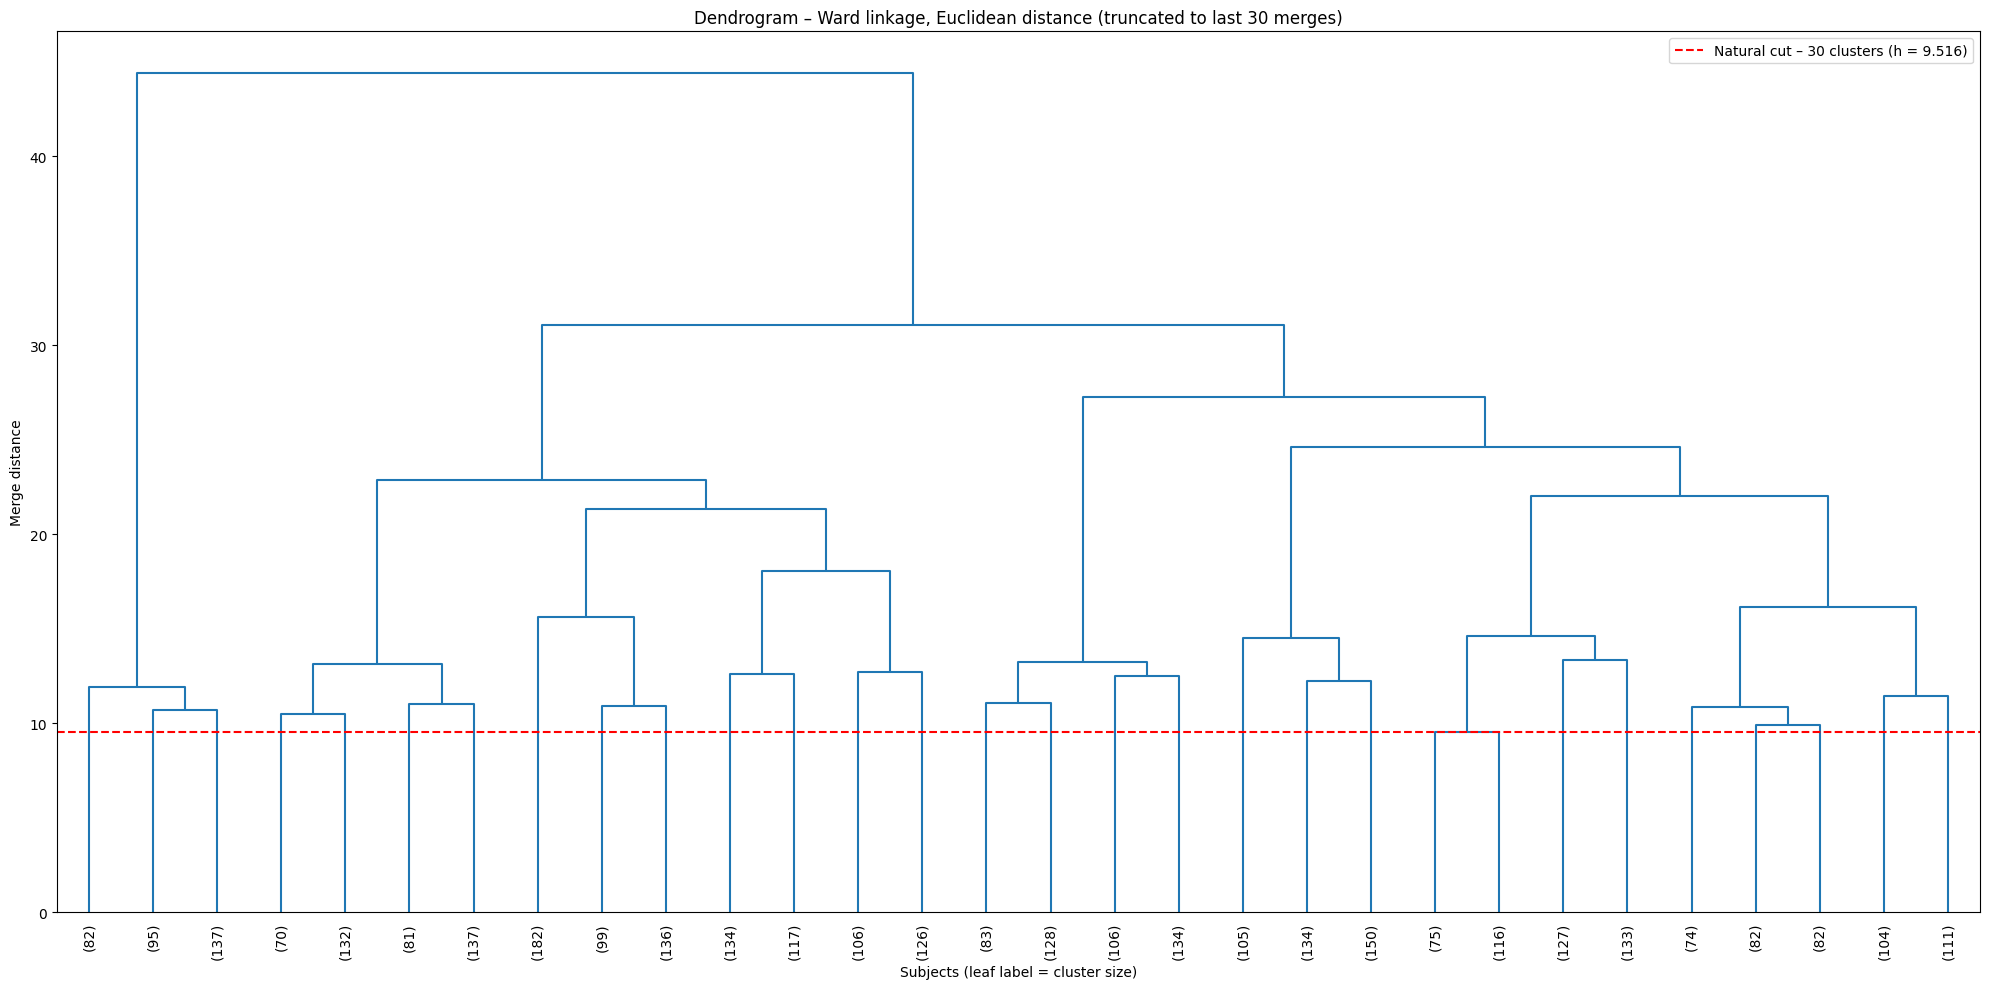

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram

# ============================================================
# 4. Construct dendrogram on normalised data
#    method = 'ward'      → Ward linkage (minimises within-cluster variance)
#    metric = 'euclidean' → Euclidean distance (mandatory for Ward)
# ============================================================
Z = linkage(X_trs_scaled, method='ward', metric='euclidean')

# ---- Natural cut: height at which the tree yields n_preview clusters --------
n_preview    = 30
# Z is sorted by merge height; the cut that gives k clusters sits at
# index -(k-1) of the last column (heights).
color_thresh = Z[-(n_preview - 1), 2]

plt.figure(figsize=(20, 10))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=n_preview,
    leaf_rotation=90.,
    leaf_font_size=10.,
    color_threshold=color_thresh
)
plt.axhline(y=color_thresh, color='red', linestyle='--',
            label=f'Natural cut – {n_preview} clusters (h = {color_thresh:.3f})')
plt.title('Dendrogram – Ward linkage, Euclidean distance (truncated to last 30 merges)')
plt.xlabel('Subjects (leaf label = cluster size)')
plt.ylabel('Merge distance')
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
# ============================================================
# 5. Identify clusters in the TRS
# ============================================================
n_clusters = 30 # As per instructions, aim for 30-35 clusters
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')

X_trs_scaled["cluster"] = cluster_labels
X_trs["cluster"] = cluster_labels

print("Number of clusters found:", len(np.unique(cluster_labels)))

Number of clusters found: 30


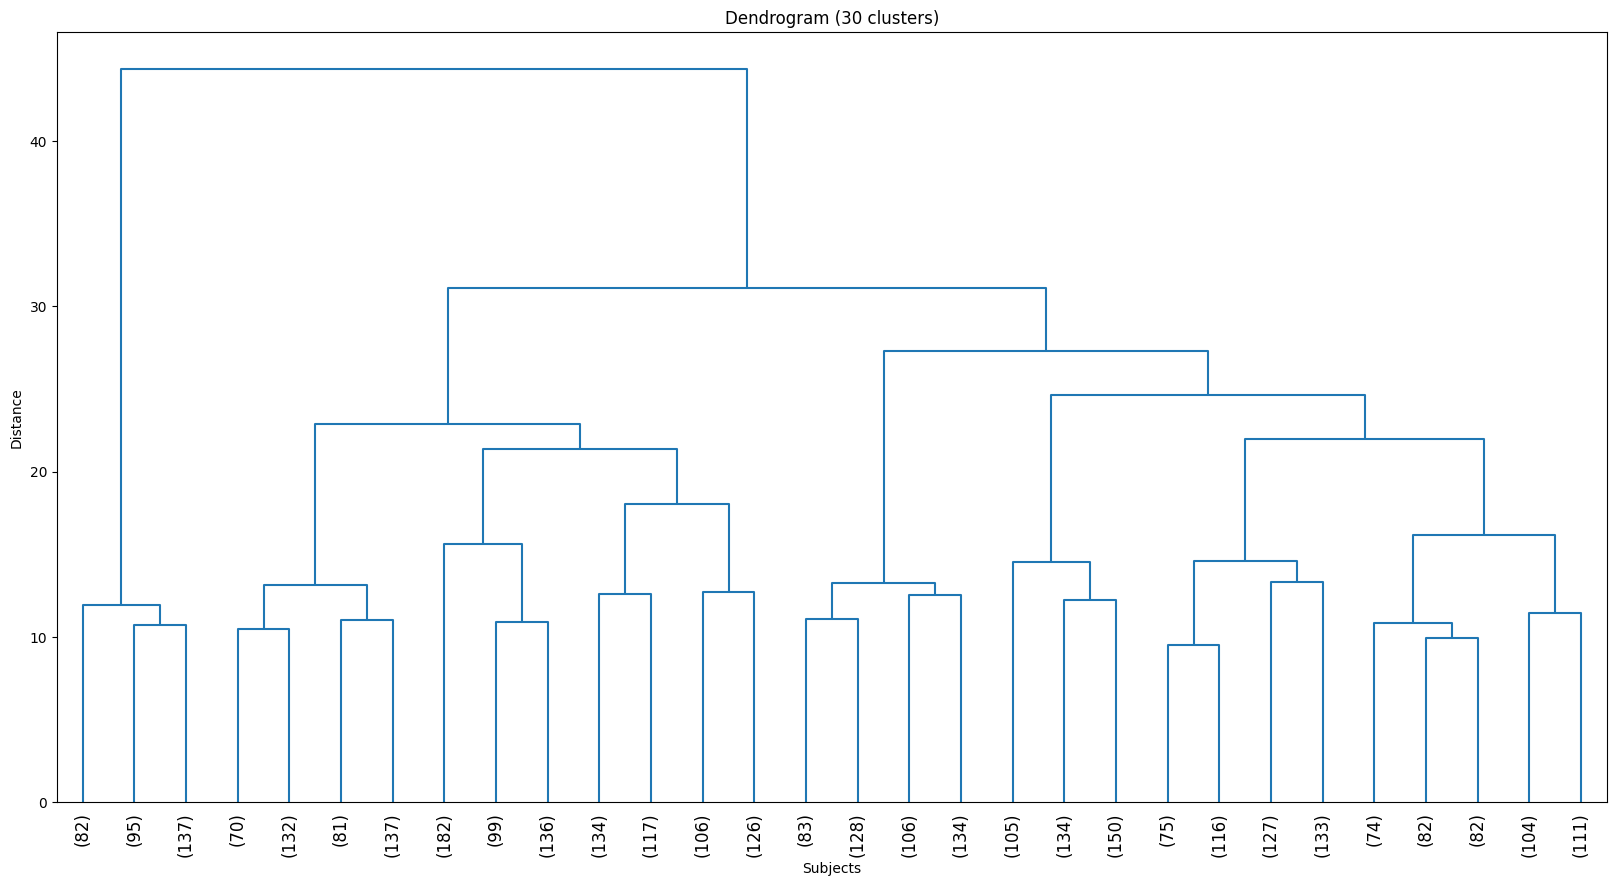

In [12]:
import numpy as np
# ============================================================
# Look the dendrogram with clusters defined
# ============================================================
plt.figure(figsize=(20, 10))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=n_clusters, # display only the last 'p' merged clusters
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=12.,  # fontsize for the x axis labels
    color_threshold=Z[-(n_clusters-1), 2]
)
plt.title(f"Dendrogram ({n_clusters} clusters)")
plt.xlabel("Subjects")
plt.ylabel("Distance")
plt.show()

In [13]:
X_trs_scaled["cluster"] = cluster_labels
X_trs["cluster"] = cluster_labels
centroids_scaled = X_trs_scaled.groupby('cluster').mean()

In [14]:
import numpy as np

MIN_CLUSTER_SIZE = 10  # clusters with fewer subjects are ignored

# Pre-compute cluster sizes once
cluster_sizes = X_trs.groupby('cluster').size()

# ============================================================
# 7. Impute subjects with missing values
# ============================================================
X_imputed = X.copy()

for subject_idx in X_missing.index:
    subject      = X.loc[subject_idx]
    observed_vars = subject.dropna().index.tolist()

    # Normalise only the observed variables
    # The scaler was fit on `input_features`, so `transform` must receive a DataFrame
    # with these same columns. `X.loc[[subject_idx]]` already provides this structure.
    subject_scaled_full = pd.DataFrame(
        scaler.transform(X.loc[[subject_idx]]),
        columns=input_features,
        index=[subject_idx]
    )
    subject_observed = subject_scaled_full.loc[subject_idx, observed_vars]

    # Manhattan distance to each centroid (on observed vars only)
    centroids_observed = centroids_scaled[observed_vars]
    distances = centroids_observed.apply(
        lambda c: np.linalg.norm(subject_observed - c, ord=1), axis=1
    )

    # Pick the nearest cluster that has >= MIN_CLUSTER_SIZE members
    closest_cluster = None
    for cid in distances.sort_values().index:
        if cluster_sizes.get(cid, 0) >= MIN_CLUSTER_SIZE:
            closest_cluster = cid
            break
    if closest_cluster is None:          # fallback: use absolute nearest
        closest_cluster = distances.idxmin()

    cluster_subjects = X_trs[X_trs['cluster'] == closest_cluster].drop(columns=['cluster'])
    missing_vars     = subject[subject.isna()].index.tolist()

    for var in missing_vars:
        if var in continuous_vars:
            mean_val = cluster_subjects[var].mean()
            std_val  = cluster_subjects[var].std()
            val = (mean_val + np.random.normal(0, std_val * 0.1)
                   if (not pd.isna(std_val) and std_val > 0) else mean_val)
            val = np.clip(val, cluster_subjects[var].min(), cluster_subjects[var].max())
            X_imputed.loc[subject_idx, var] = val

        elif var in integer_vars:
            lo = cluster_subjects[var].quantile(0.40)
            hi = cluster_subjects[var].quantile(0.60)
            if pd.isna(lo) or pd.isna(hi) or hi < lo:
                val = (cluster_subjects[var].mode()[0]
                       if not cluster_subjects[var].mode().empty
                       else cluster_subjects[var].mean())
            else:
                val = np.random.uniform(lo, hi)
            X_imputed.loc[subject_idx, var] = round(val)

        elif var in categorical_vars:
            modes = cluster_subjects[var].mode()
            X_imputed.loc[subject_idx, var] = modes[0] if not modes.empty else df[var].mode()[0]

# ============================================================
# 8. Rebuild final dataset
# ============================================================
df_final = df.copy()
df_final[input_features] = X_imputed[input_features]


In [15]:
print("Shape of df_final:", df_final.shape)
print("Total missing values in df_final:", df_final.isna().sum().sum())
display(df_final.head())

Shape of df_final: (3893, 76)
Total missing values in df_final: 0


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,gender,age,weight,charlson_comorbidity_index,...,first_plateau_pressure,std_plateau_pressure,vent_duration_hours,comorb_total,comorb_catcardiac_cardiovascular,comorb_catrespiratory_pulmonary,comorb_catmetabolic_endocrine_renal,comorb_catneurological_neuromuscular_psychiatric,comorb_catsystemic_immune_oncologic,outcome
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,1,66,113.3,3,...,19.0,1.909727,96.0,1,0,0,1,0,0,2
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,1,53,106.7,5,...,10.0,8.337289,230.0,5,0,1,1,0,0,1
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,0,66,46.1,6,...,17.0,1.224745,34.0,4,0,0,1,0,0,1
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,1,49,106.0,1,...,11.0,4.877563,399.0,4,1,0,1,1,0,2
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,0,77,49.3,7,...,17.0,3.239768,155.0,4,1,0,1,0,1,2


---
## Visualisation: Clustering Global Imputation – Imputed Variables

For each variable with at least one missing value, distribution of **all patients** before (complete cases only) vs. after imputation.

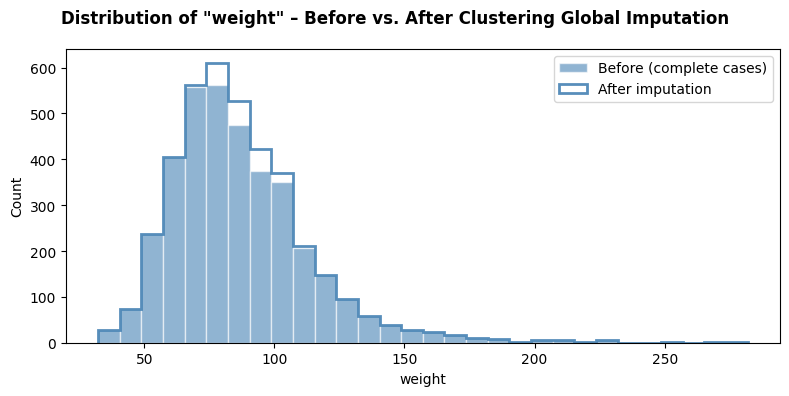

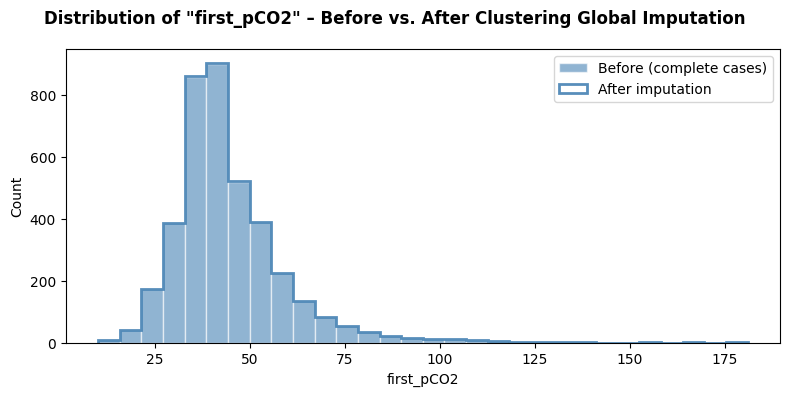

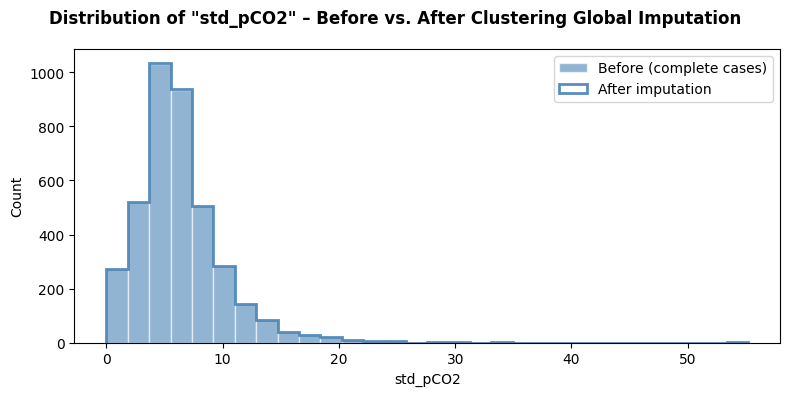

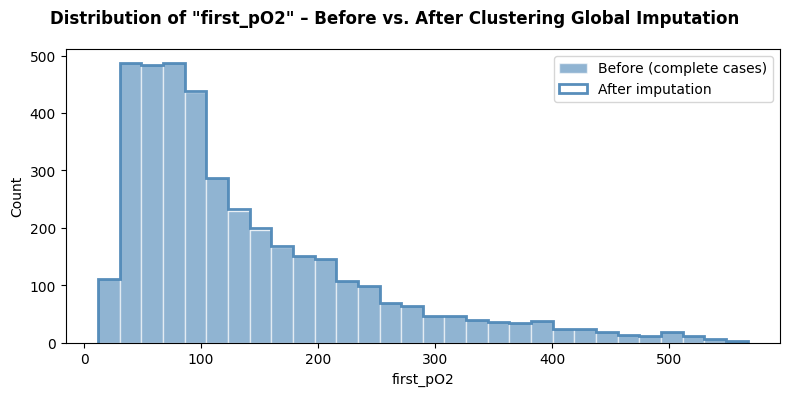

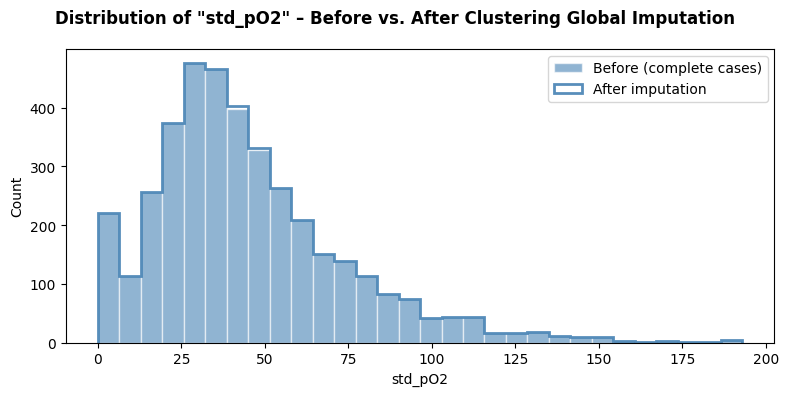

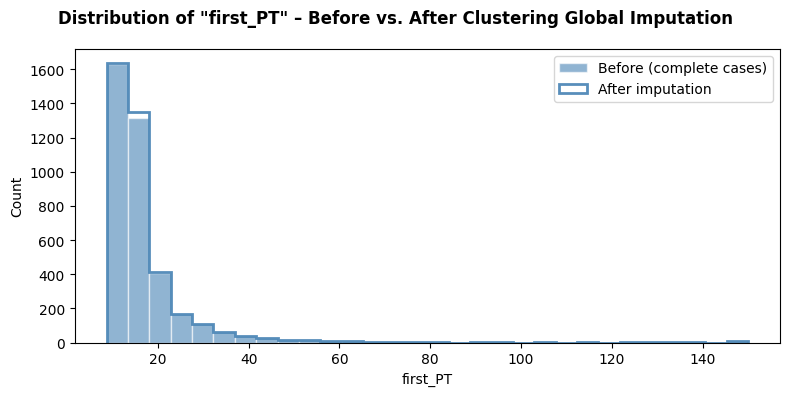

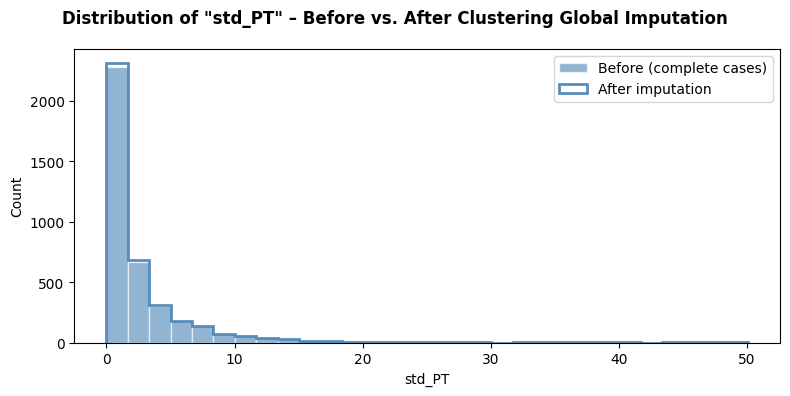

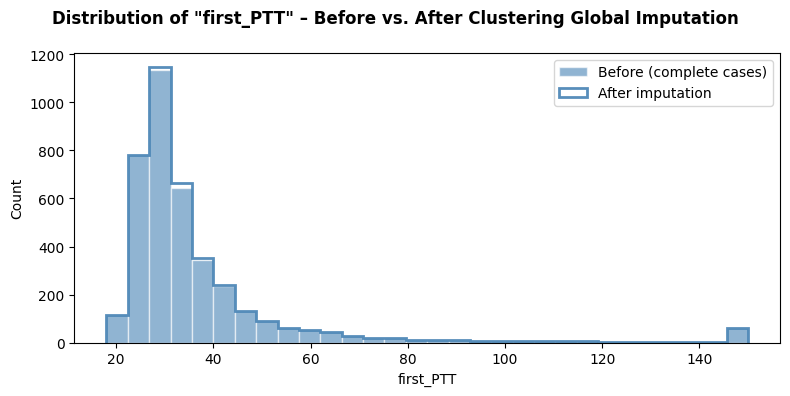

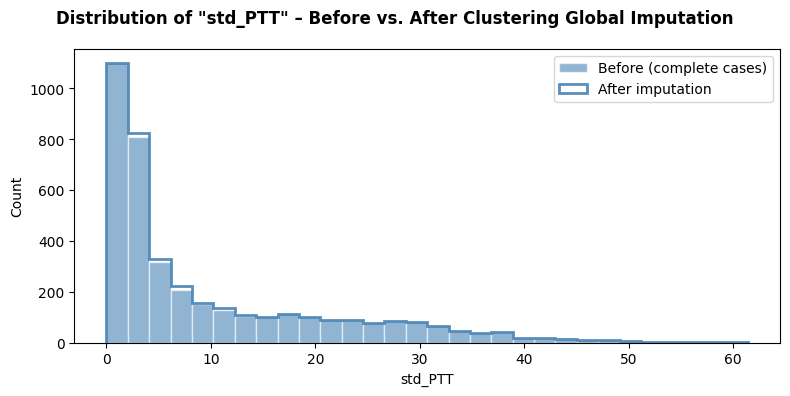

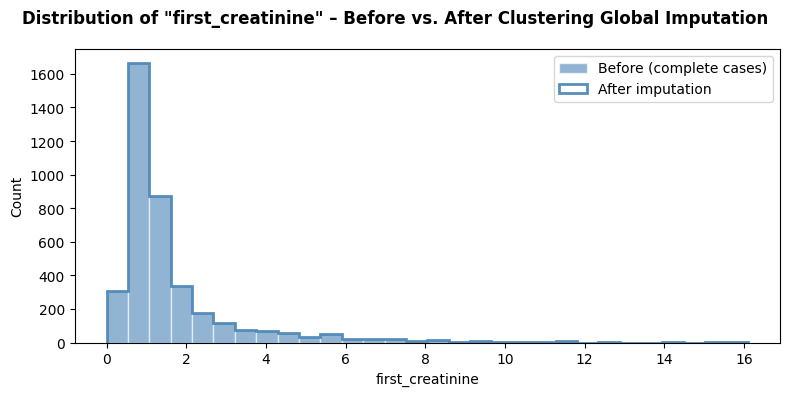

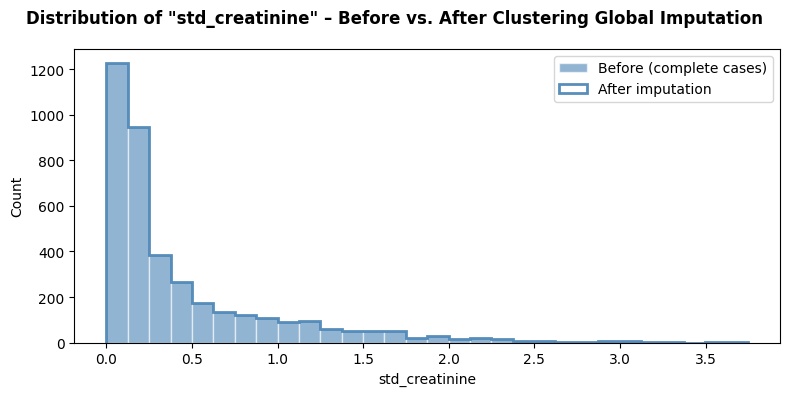

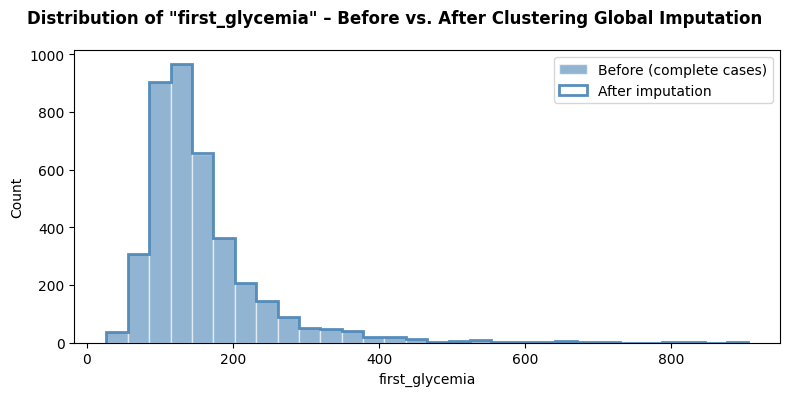

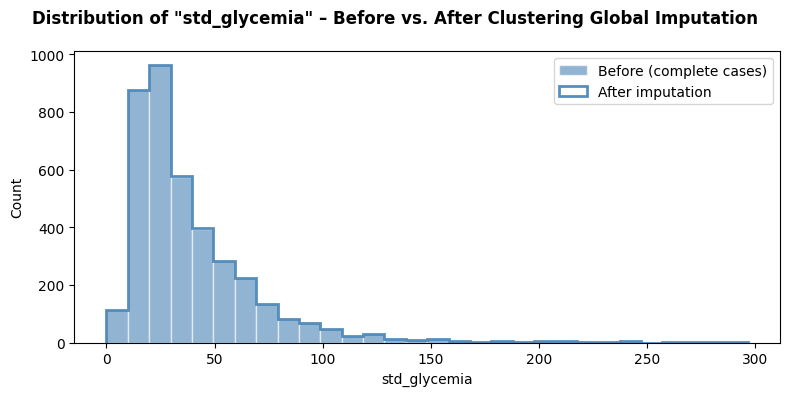

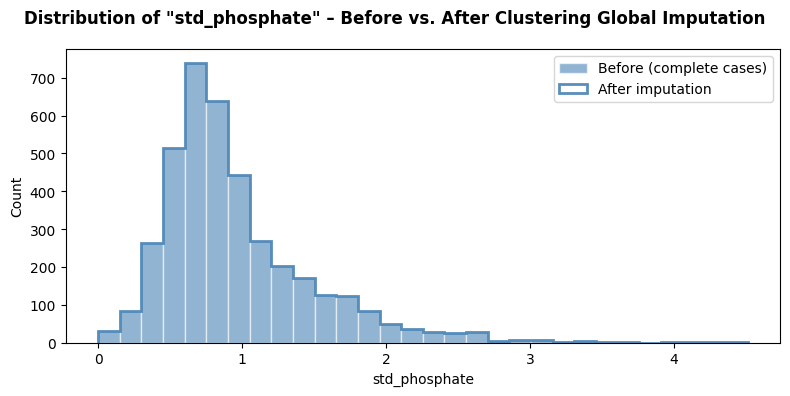

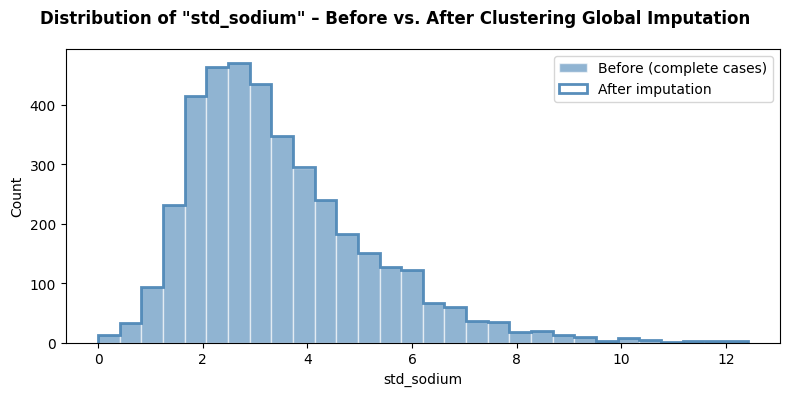

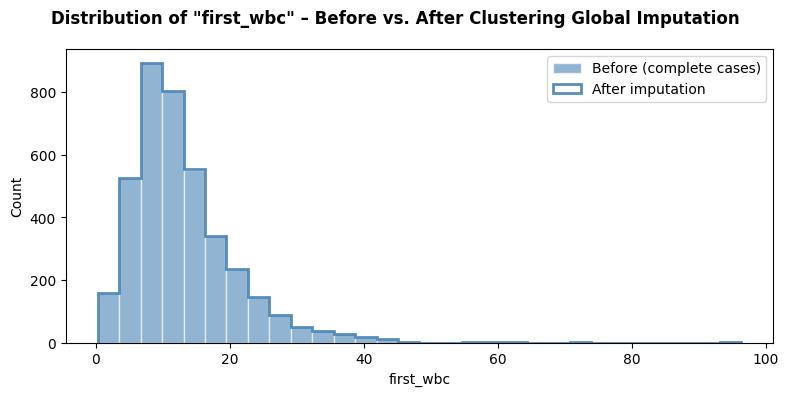

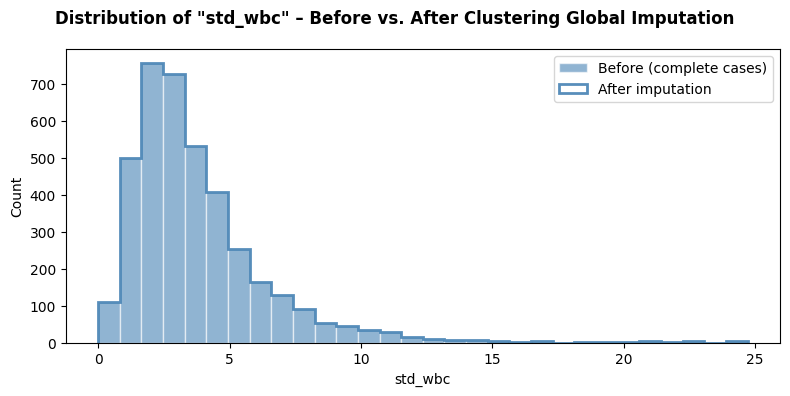

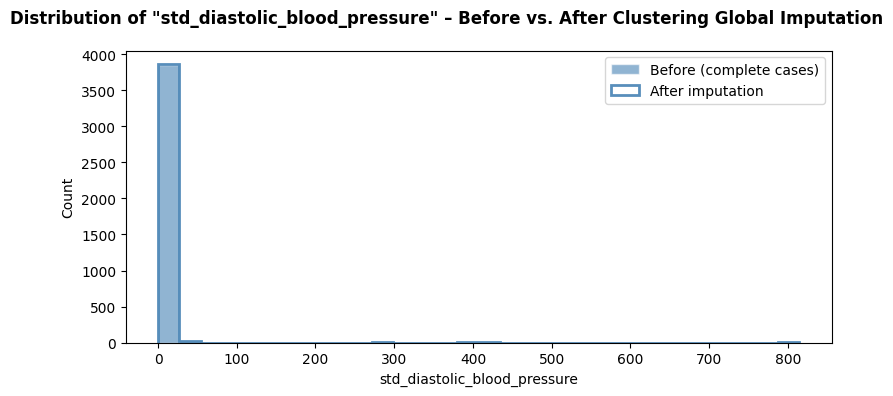

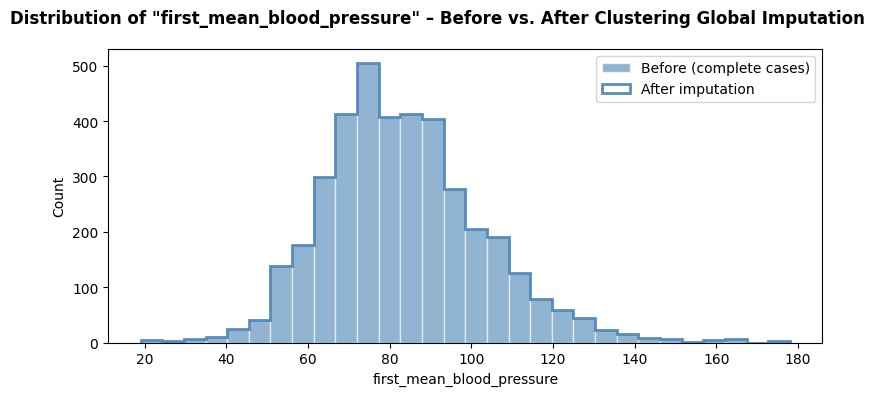

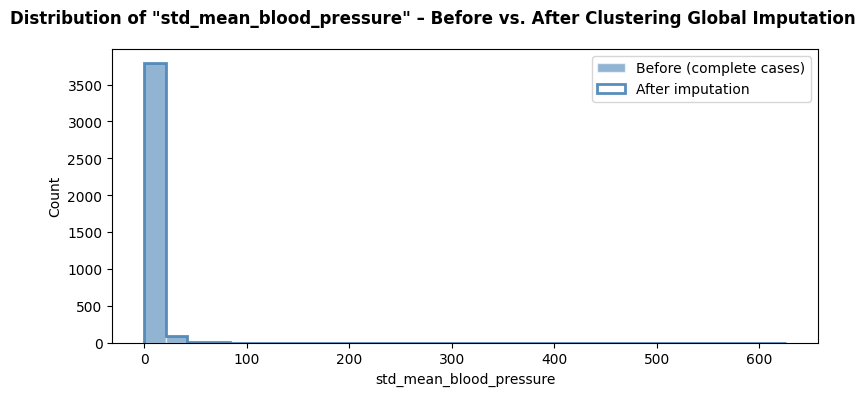

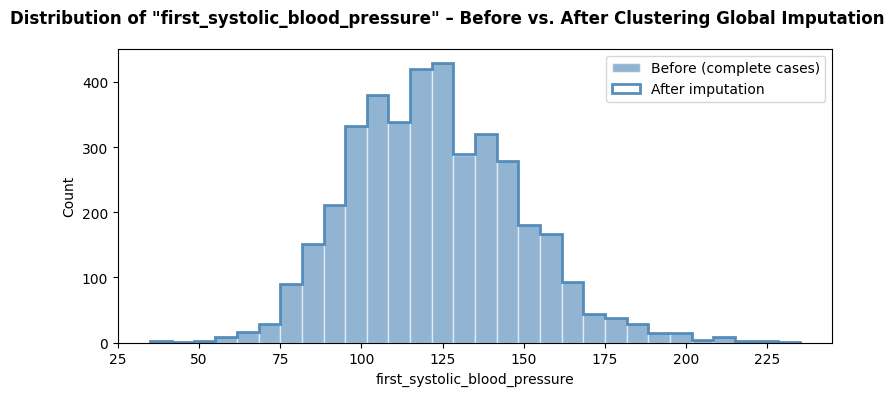

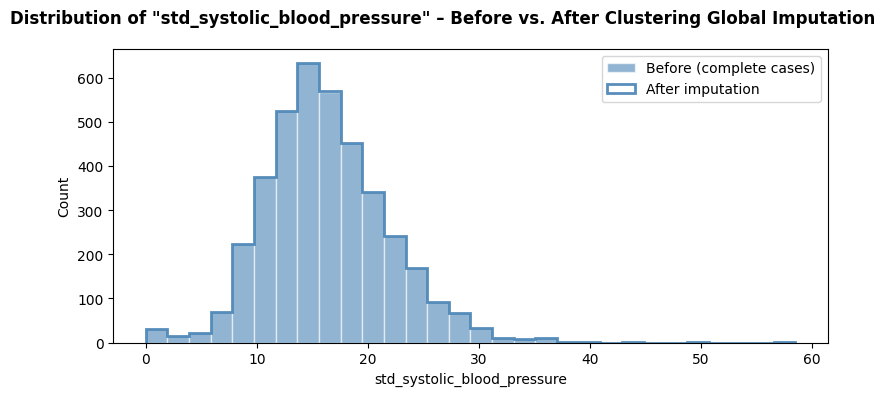

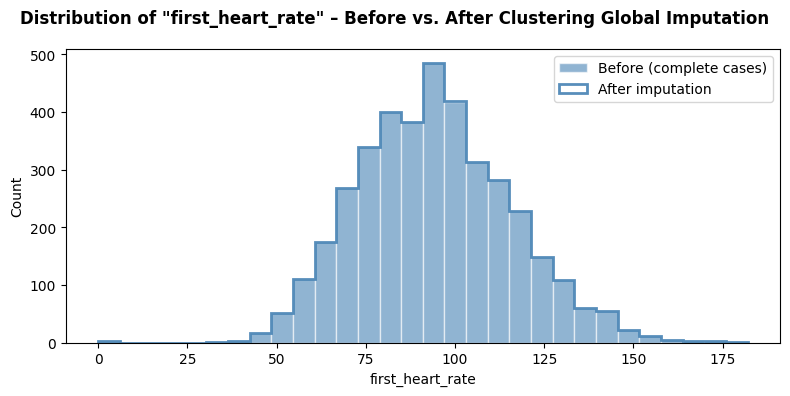

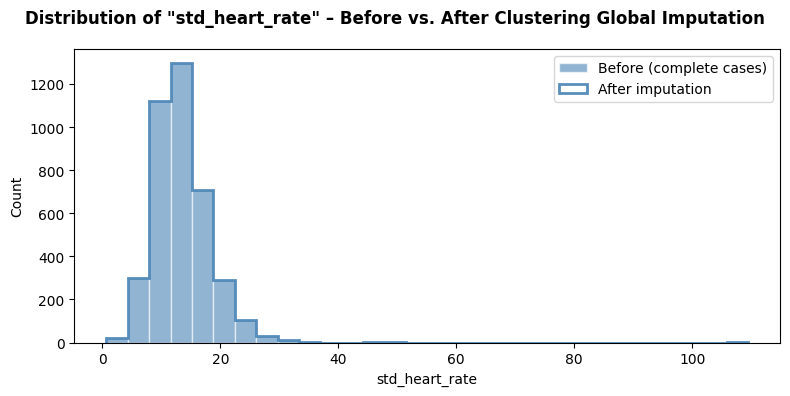

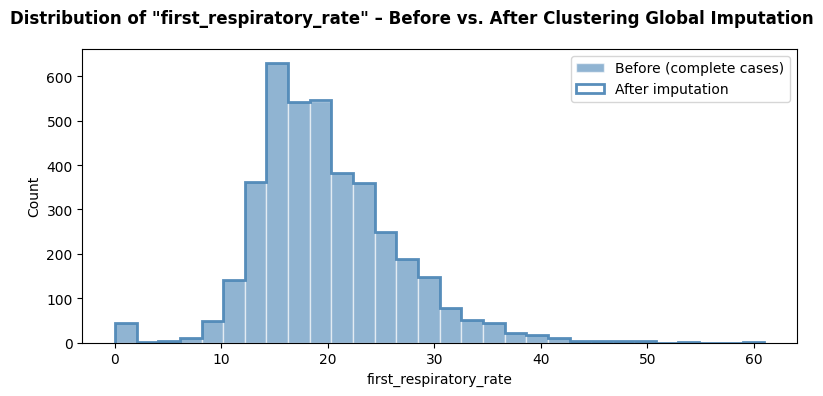

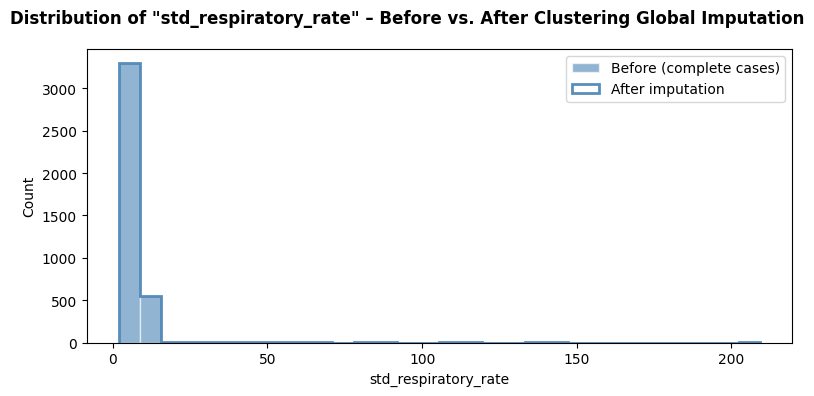

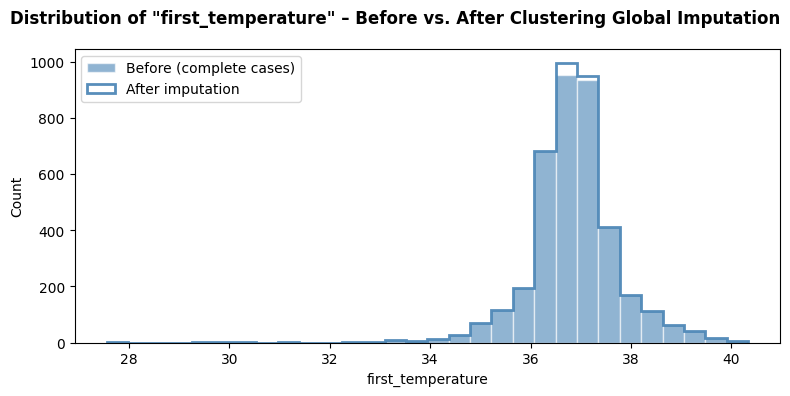

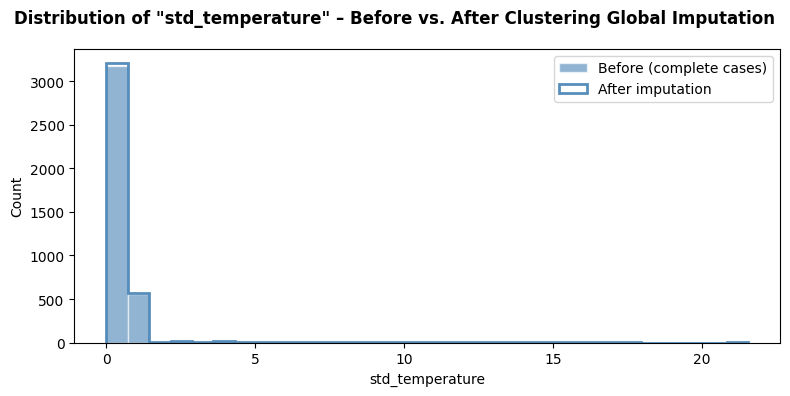

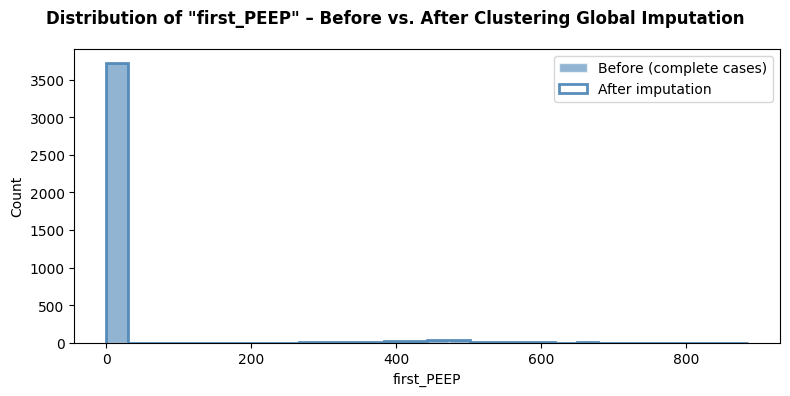

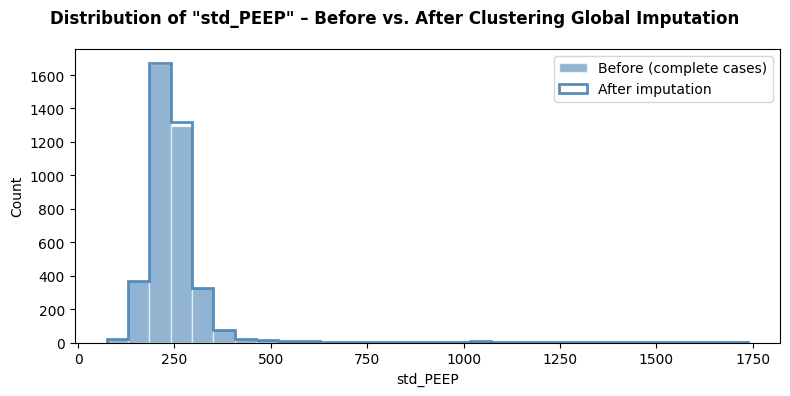

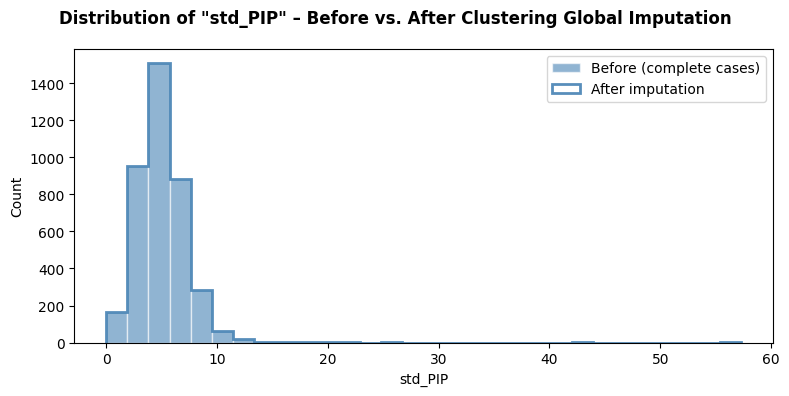

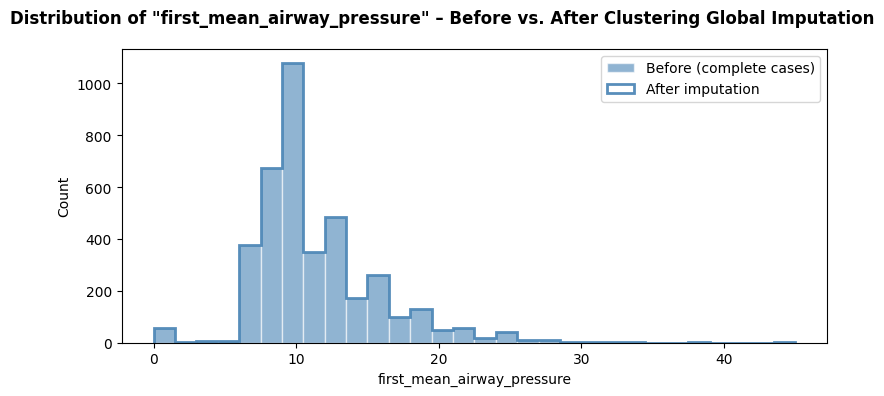

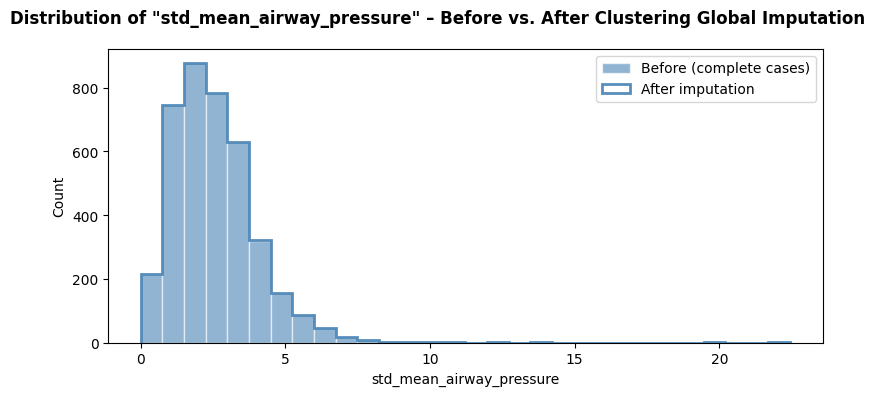

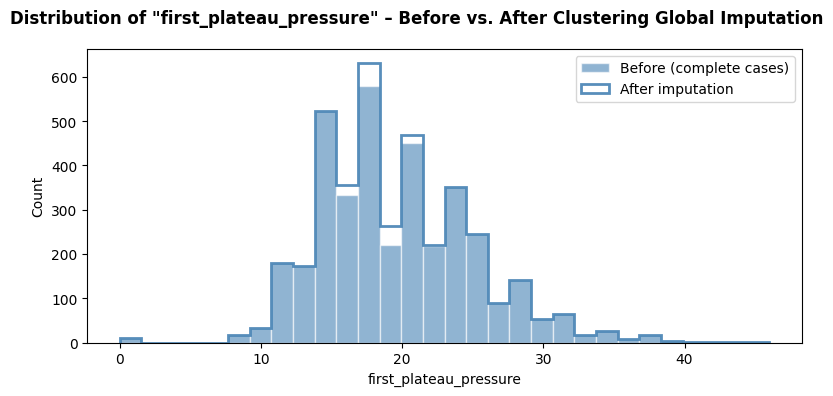

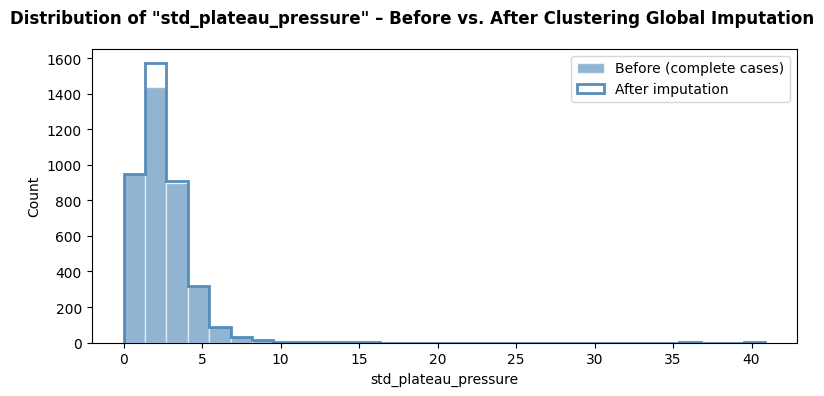

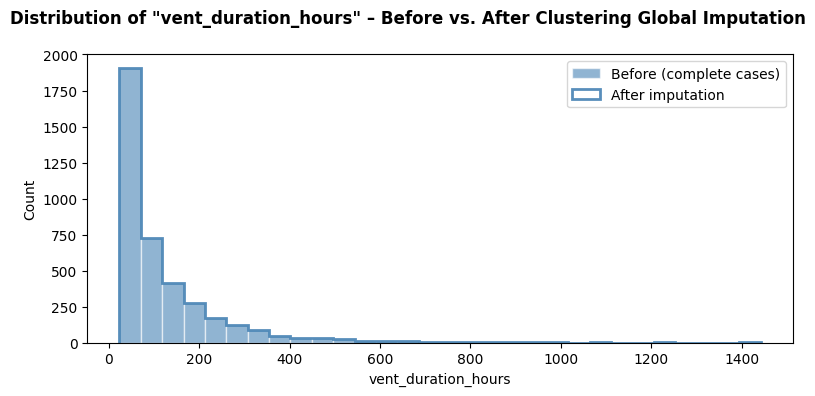

In [16]:
import matplotlib.pyplot as plt

vars_with_mv = [col for col in input_features if df[col].isna().any()]

for col in vars_with_mv:
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.suptitle(
        f'Distribution of "{col}" – Before vs. After Clustering Global Imputation',
        fontsize=12, fontweight='bold'
    )
    before = df[col].dropna()
    after  = df_final[col].dropna()
    bins = min(30, max(5, int(len(after) ** 0.5)))
    ax.hist(before, bins=bins, alpha=0.6, color='steelblue',
            label='Before (complete cases)', edgecolor='white')
    ax.hist(after,  bins=bins, alpha=0.9, color='steelblue',
            label='After imputation', histtype='step', linewidth=2)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 5) Final saving

In [17]:
new_sheet_name = "Dataset_step_3c"

with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_final.to_excel(writer, sheet_name=new_sheet_name, index=False)

print(f"Dataset saved to new sheet: '{new_sheet_name}' in '{file_path}'")

Dataset saved to new sheet: 'Dataset_step_3c' in 'Dataset_DAPPC_2026.xlsx'


---
## Hierarchical Clustering-based Missing Value Imputation by Outcome Class

In this section we perform clustering-based imputation **separately for each outcome class (0 / 1 / 2)**.

Why?
- Patients from different outcome classes may have different clinical distributions.
- Imputing within class preserves intra-class similarity.


In [18]:
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, fcluster

MIN_CLUSTER_SIZE = 10  # clusters smaller than this are ignored during imputation

imputed_dfs_by_class = []
outcome_classes = df['outcome'].unique()

# Number of clusters per class (natural-cut target)
n_clusters_by_class = {0: 20, 1: 25, 2: 25}

print(f'Classes to process: {sorted(outcome_classes)}')

for outcome_class in sorted(outcome_classes):
    print(f'\n=== Class {outcome_class} ===')

    df_class  = df[df['outcome'] == outcome_class].copy()
    X_class   = df_class[input_features].copy()

    # TRS = subjects without ANY missing value (do NOT drop MVs from df/X_class)
    X_trs_class     = X_class.dropna()
    X_missing_class = X_class[X_class.isna().any(axis=1)]

    print(f'  Input matrix shape : {X_class.shape}')
    print(f'  TRS size           : {X_trs_class.shape[0]}')
    print(f'  Subjects with MVs  : {X_missing_class.shape[0]}')

    if X_trs_class.empty or X_missing_class.empty:
        print('  Nothing to impute – appending as-is.')
        imputed_dfs_by_class.append(df_class)
        continue
    if X_trs_class.shape[0] < 2:
        print('  TRS too small to cluster – skipping.')
        imputed_dfs_by_class.append(df_class)
        continue

    # ── Normalise TRS ────────────────────────────────────────────────────────
    scaler_class = MinMaxScaler()
    X_trs_scaled_class = pd.DataFrame(
        scaler_class.fit_transform(X_trs_class),
        columns=X_trs_class.columns,
        index=X_trs_class.index
    )

    # ── Dendrogram (Ward + Euclidean) ─────────────────────────────────────────
    Z_class = linkage(X_trs_scaled_class, method='ward', metric='euclidean')

    # ── Natural cut: use n_clusters directly as maxclust parameter ────────────
    target_n = n_clusters_by_class.get(outcome_class, 25)
    n_clusters_class = min(target_n, X_trs_class.shape[0] - 1)
    if n_clusters_class < 2:
        print('  Cannot form multiple clusters – skipping.')
        imputed_dfs_by_class.append(df_class)
        continue

    cluster_labels_class = fcluster(Z_class, n_clusters_class, criterion='maxclust')

    # Assign cluster labels (work on copies to avoid SettingWithCopyWarning)
    X_trs_scaled_class = X_trs_scaled_class.copy()
    X_trs_class        = X_trs_class.copy()
    X_trs_scaled_class['cluster'] = cluster_labels_class
    X_trs_class['cluster']        = cluster_labels_class

    print(f'  Actual clusters    : {len(np.unique(cluster_labels_class))}')

    # ── Cluster sizes & small-cluster report ─────────────────────────────────
    cluster_sizes_class = X_trs_class.groupby('cluster').size()
    small = cluster_sizes_class[cluster_sizes_class < MIN_CLUSTER_SIZE].index.tolist()
    if small:
        print(f'  Clusters with < {MIN_CLUSTER_SIZE} subjects (will be skipped): {small}')

    # ── Centroids on normalised data ─────────────────────────────────────────
    centroids_scaled_class = X_trs_scaled_class.groupby('cluster').mean()

    X_imputed_class = X_class.copy()

    for subject_idx in X_missing_class.index:
        subject       = X_class.loc[subject_idx]
        observed_vars = subject.dropna().index.tolist()

        if not observed_vars:
            print(f'  Subject {subject_idx}: all values missing – skipping.')
            continue

        # Normalise observed vars only
        # The scaler was fit on `input_features`, so `transform` must receive a DataFrame
        # with these same columns. `X_class.loc[[subject_idx]]` already provides this structure.
        subject_scaled_full = pd.DataFrame(
            scaler_class.transform(X_class.loc[[subject_idx]]),
            columns=input_features,
            index=[subject_idx]
        )
        subject_observed = subject_scaled_full.loc[subject_idx, observed_vars]

        # Manhattan distance to centroids (observed vars only)
        centroids_observed = centroids_scaled_class[observed_vars]
        distances = centroids_observed.apply(
            lambda c: np.linalg.norm(subject_observed - c, ord=1), axis=1
        )

        # Pick nearest cluster with >= MIN_CLUSTER_SIZE members
        closest_cluster = None
        for cid in distances.sort_values().index:
            if cluster_sizes_class.get(cid, 0) >= MIN_CLUSTER_SIZE:
                closest_cluster = cid
                break
        if closest_cluster is None:
            closest_cluster = distances.idxmin()  # fallback

        cluster_subjects = X_trs_class[X_trs_class['cluster'] == closest_cluster].drop(columns=['cluster'])
        missing_vars     = subject[subject.isna()].index.tolist()

        for var in missing_vars:
            if var in continuous_vars:
                mean_val = cluster_subjects[var].mean()
                std_val  = cluster_subjects[var].std()
                val = (mean_val + np.random.normal(0, std_val * 0.1)
                       if (not pd.isna(std_val) and std_val > 0) else mean_val)
                val = np.clip(val, cluster_subjects[var].min(), cluster_subjects[var].max())
                X_imputed_class.loc[subject_idx, var] = val

            elif var in integer_vars:
                lo = cluster_subjects[var].quantile(0.40)
                hi = cluster_subjects[var].quantile(0.60)
                if pd.isna(lo) or pd.isna(hi) or hi < lo:
                    val = (cluster_subjects[var].mode()[0]
                           if not cluster_subjects[var].mode().empty
                           else cluster_subjects[var].mean())
                else:
                    val = np.random.uniform(lo, hi)
                X_imputed_class.loc[subject_idx, var] = round(val)

            elif var in categorical_vars:
                modes = cluster_subjects[var].mode()
                X_imputed_class.loc[subject_idx, var] = (
                    modes[0] if not modes.empty else df[var].mode()[0]
                )

    df_class[input_features] = X_imputed_class[input_features]
    imputed_dfs_by_class.append(df_class)

# ── Reassemble full dataset ───────────────────────────────────────────────────
df_final_by_class = pd.concat(imputed_dfs_by_class).sort_index()

print('\n=== Imputation by class complete ===')
print('Shape              :', df_final_by_class.shape)
print('Remaining MVs      :', df_final_by_class.isna().sum().sum())
display(df_final_by_class.head())


Classes to process: [np.int64(0), np.int64(1), np.int64(2)]

=== Class 0 ===
  Input matrix shape : (776, 69)
  TRS size           : 700
  Subjects with MVs  : 76
  Actual clusters    : 20

=== Class 1 ===
  Input matrix shape : (1948, 69)
  TRS size           : 1654
  Subjects with MVs  : 294
  Actual clusters    : 25

=== Class 2 ===
  Input matrix shape : (1169, 69)
  TRS size           : 1024
  Subjects with MVs  : 145
  Actual clusters    : 25

=== Imputation by class complete ===
Shape              : (3893, 76)
Remaining MVs      : 0


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,gender,age,weight,charlson_comorbidity_index,...,first_plateau_pressure,std_plateau_pressure,vent_duration_hours,comorb_total,comorb_catcardiac_cardiovascular,comorb_catrespiratory_pulmonary,comorb_catmetabolic_endocrine_renal,comorb_catneurological_neuromuscular_psychiatric,comorb_catsystemic_immune_oncologic,outcome
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,1,66,113.3,3,...,19.0,1.909727,96.0,1,0,0,1,0,0,2
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,1,53,106.7,5,...,10.0,8.337289,230.0,5,0,1,1,0,0,1
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,0,66,46.1,6,...,17.0,1.224745,34.0,4,0,0,1,0,0,1
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,1,49,106.0,1,...,11.0,4.877563,399.0,4,1,0,1,1,0,2
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,0,77,49.3,7,...,17.0,3.239768,155.0,4,1,0,1,0,1,2


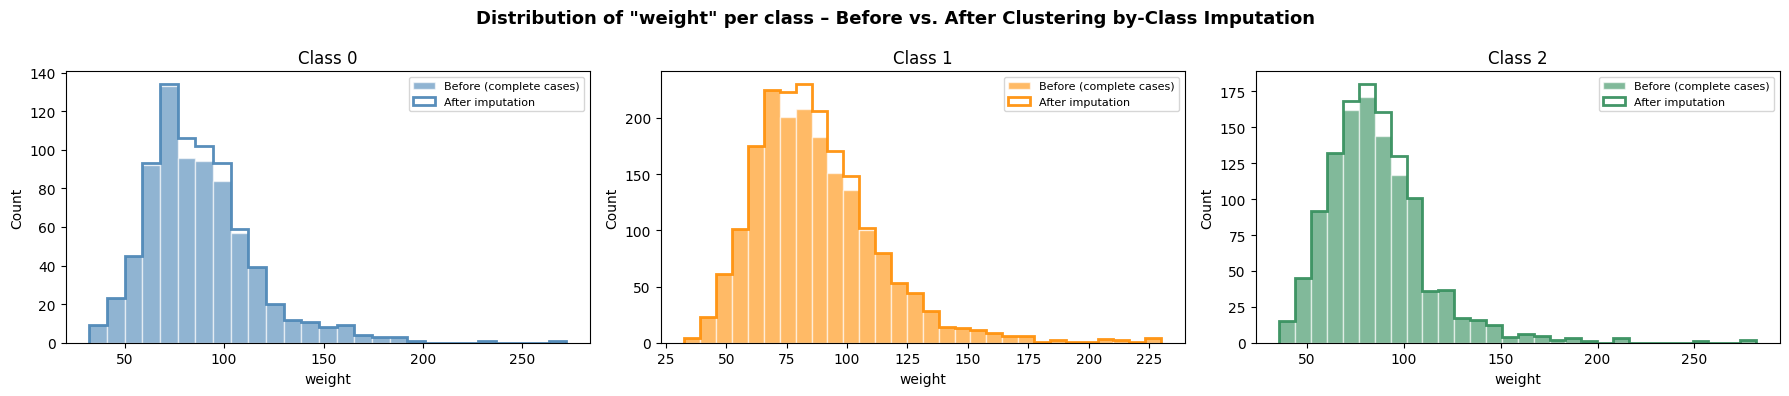

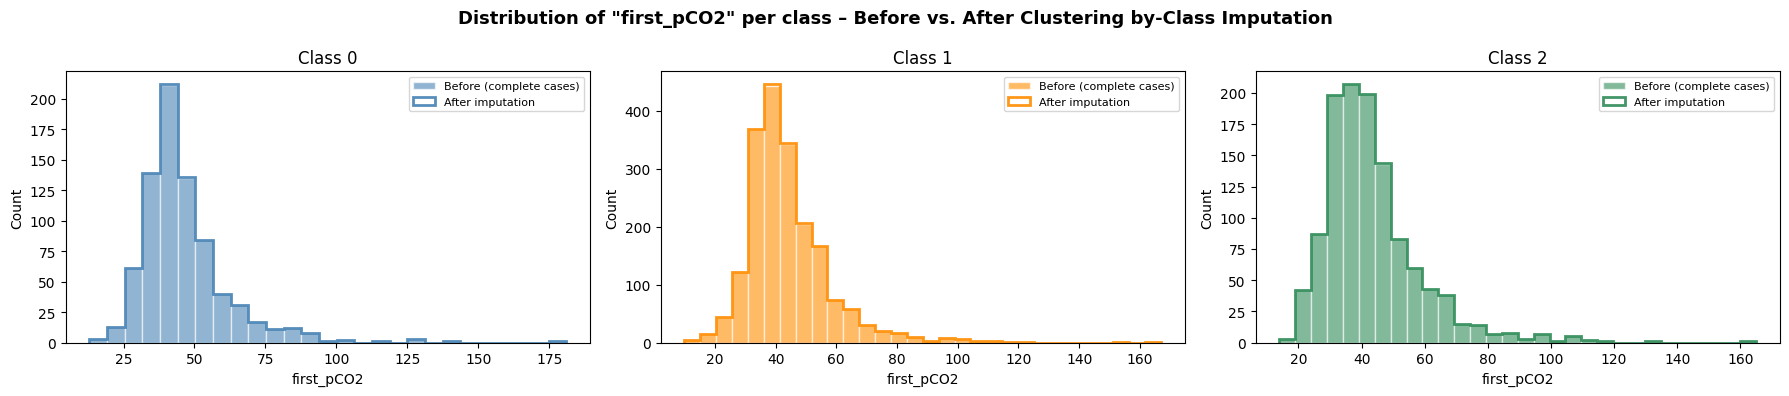

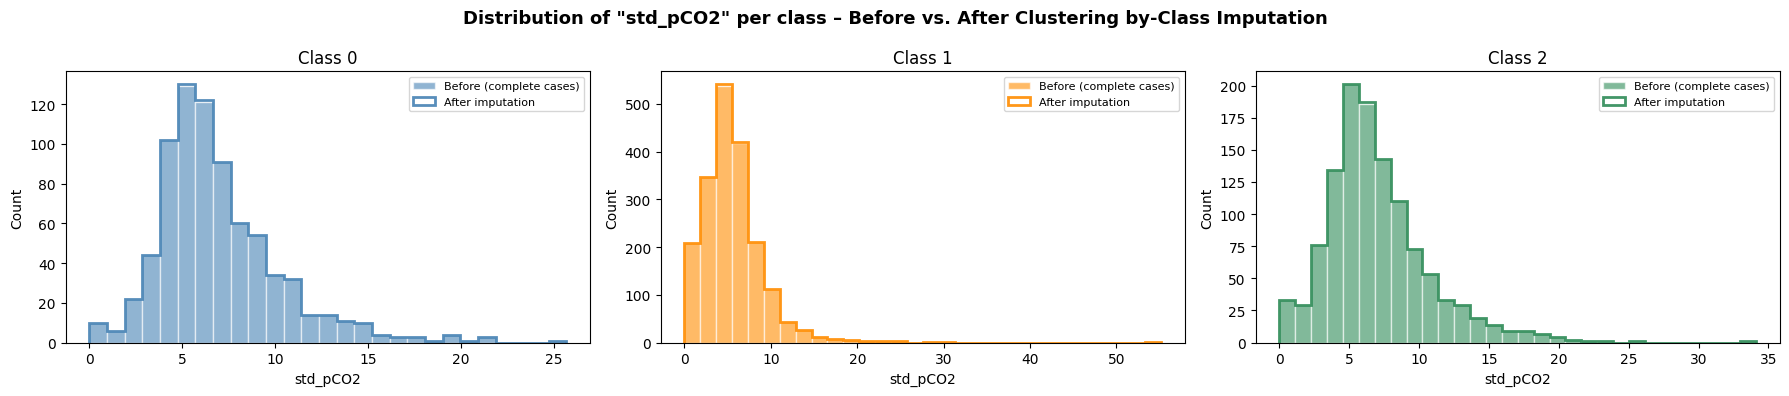

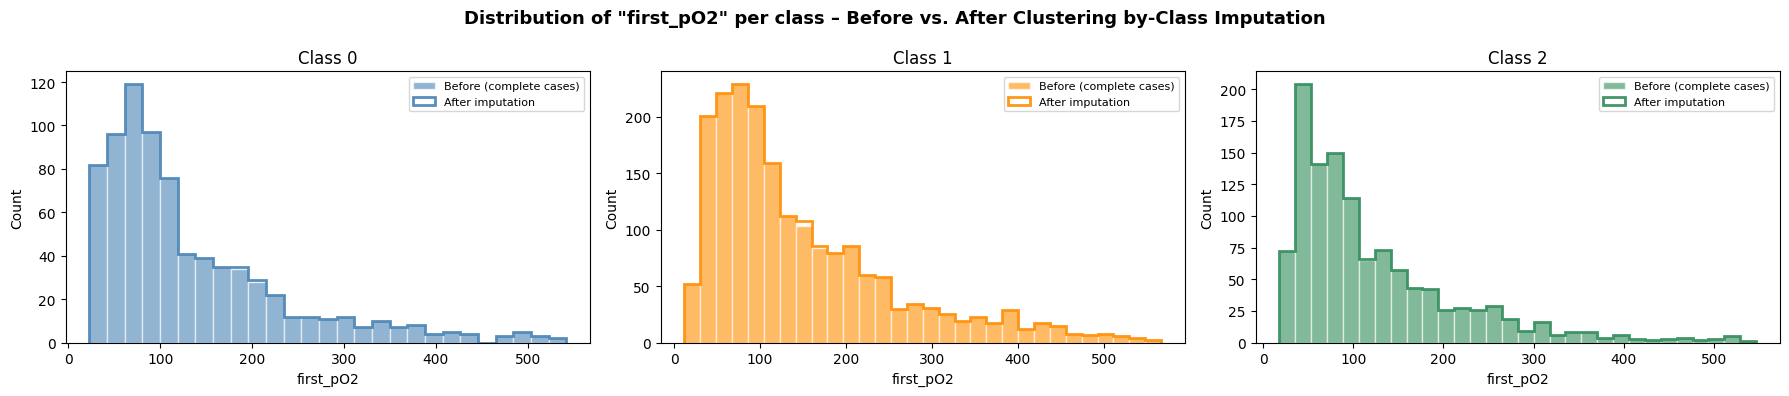

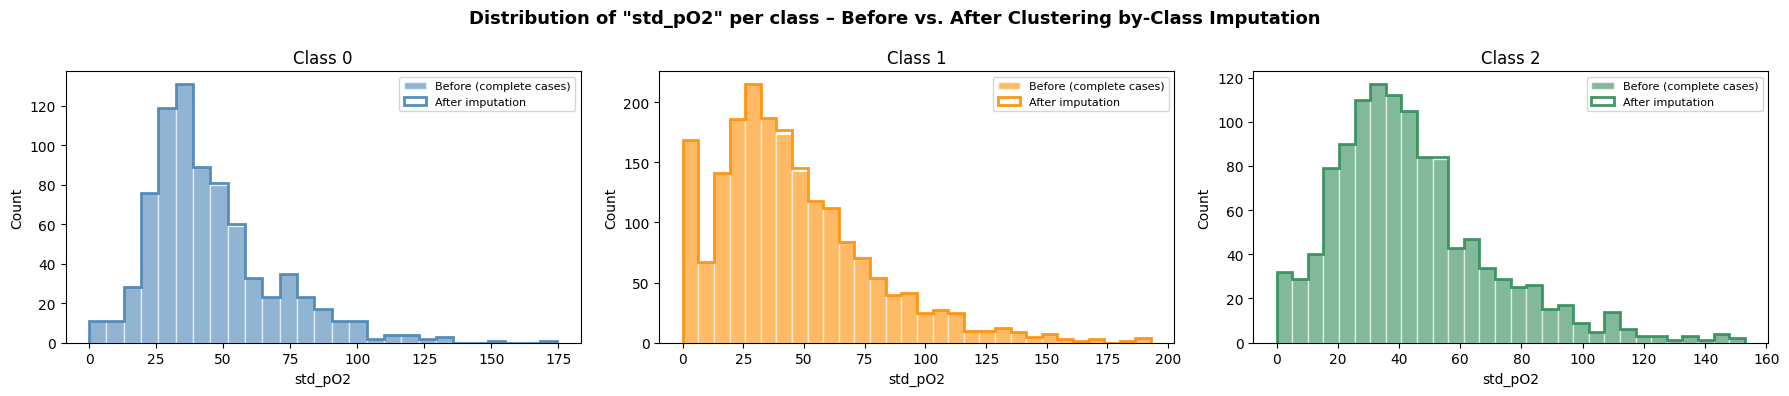

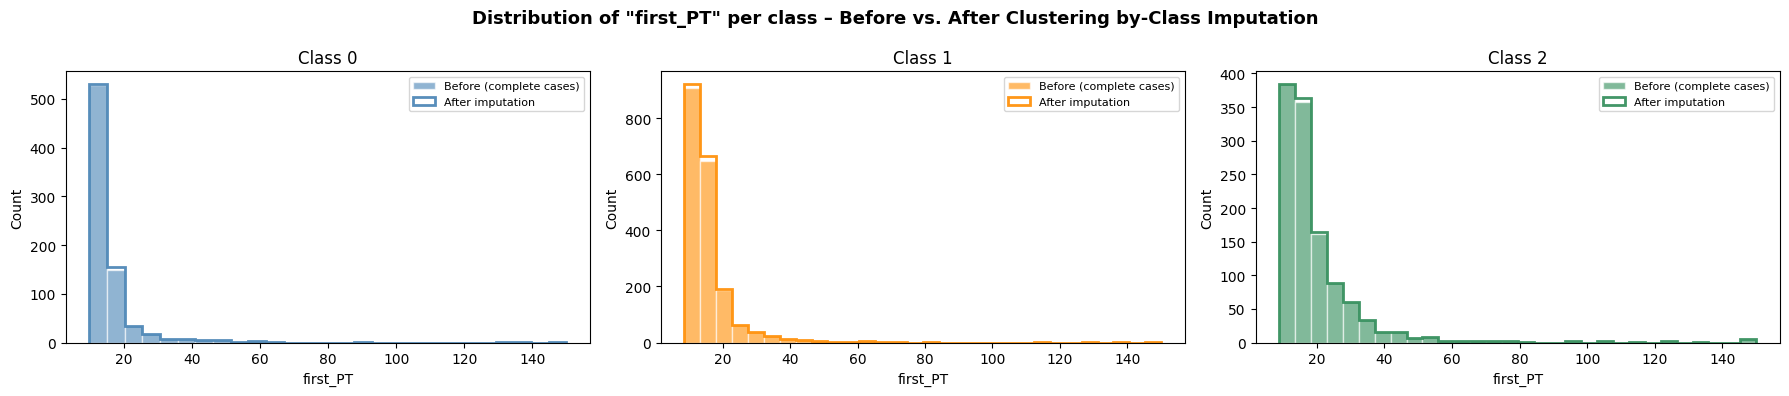

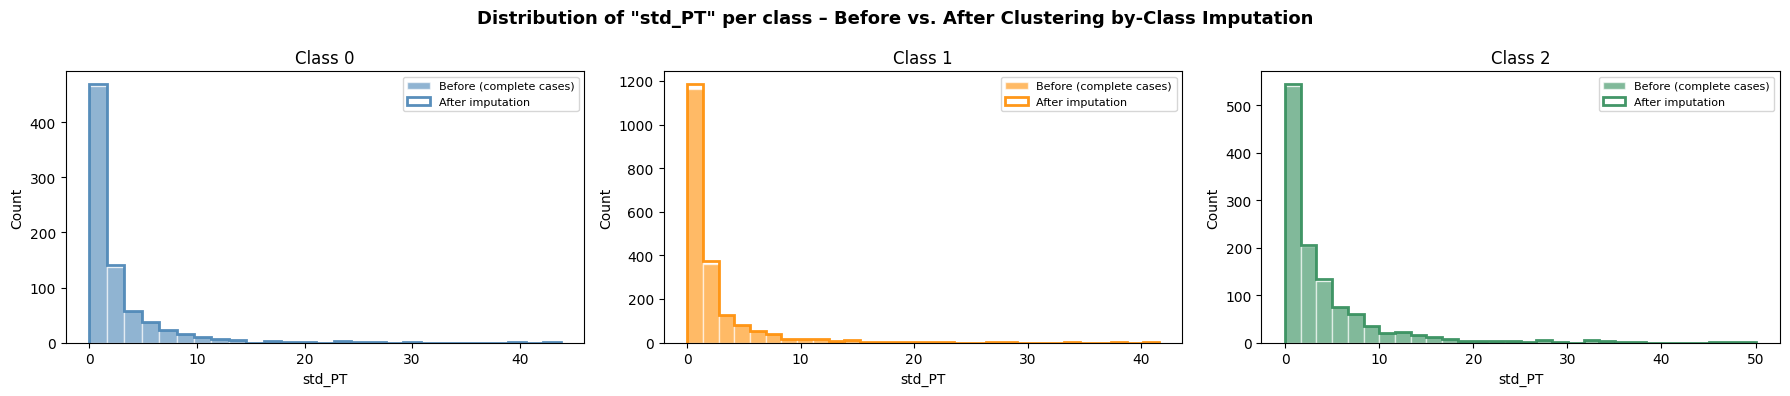

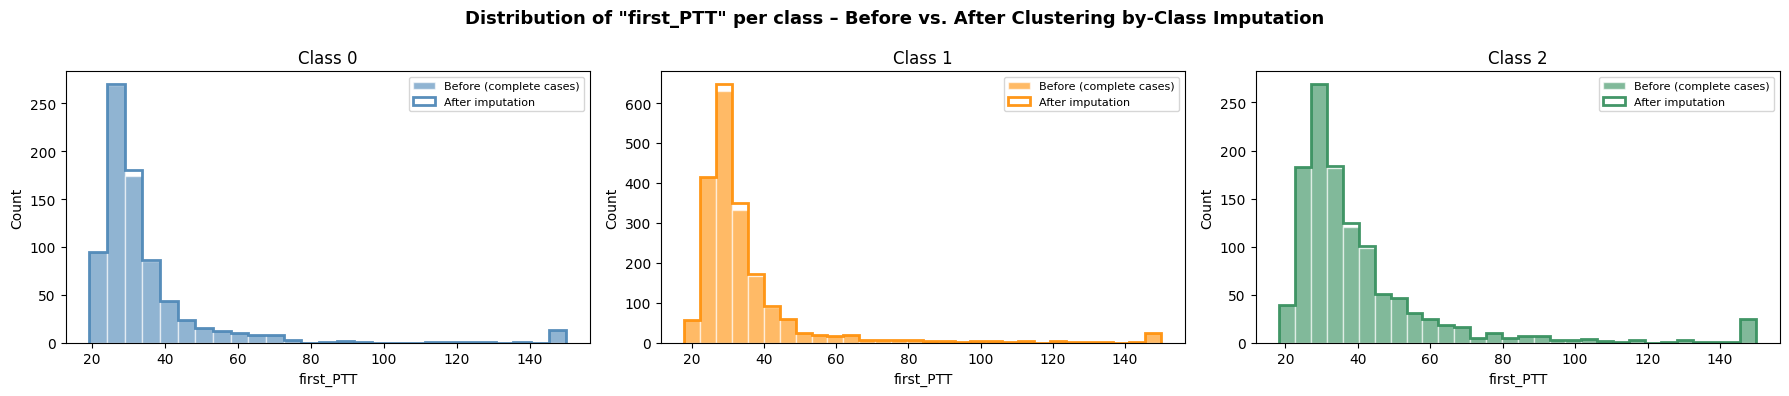

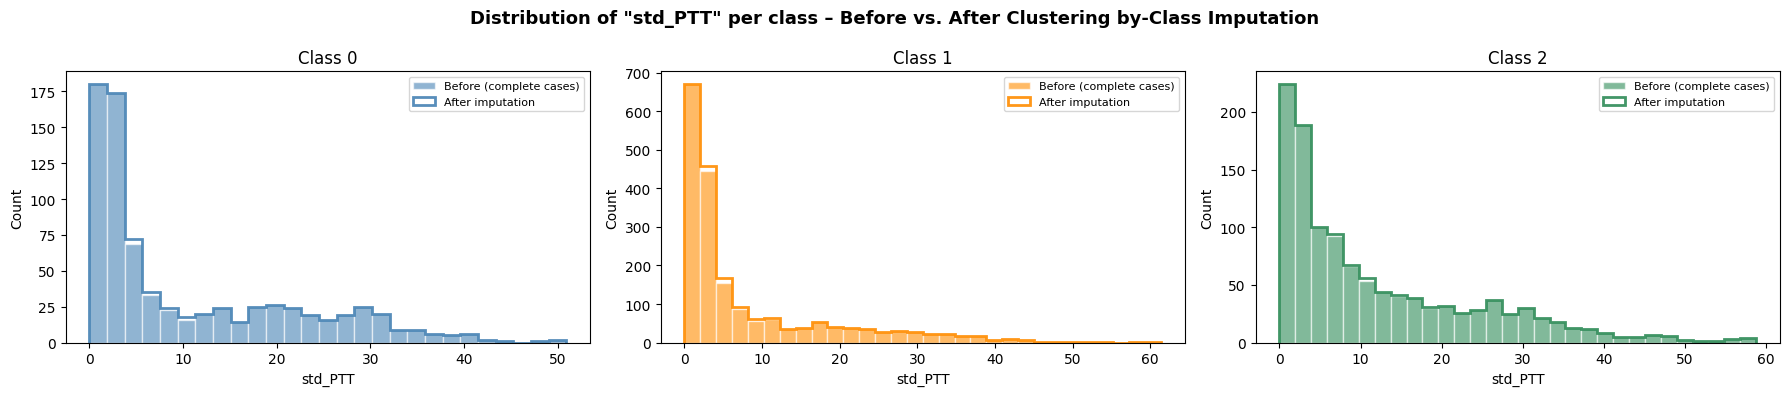

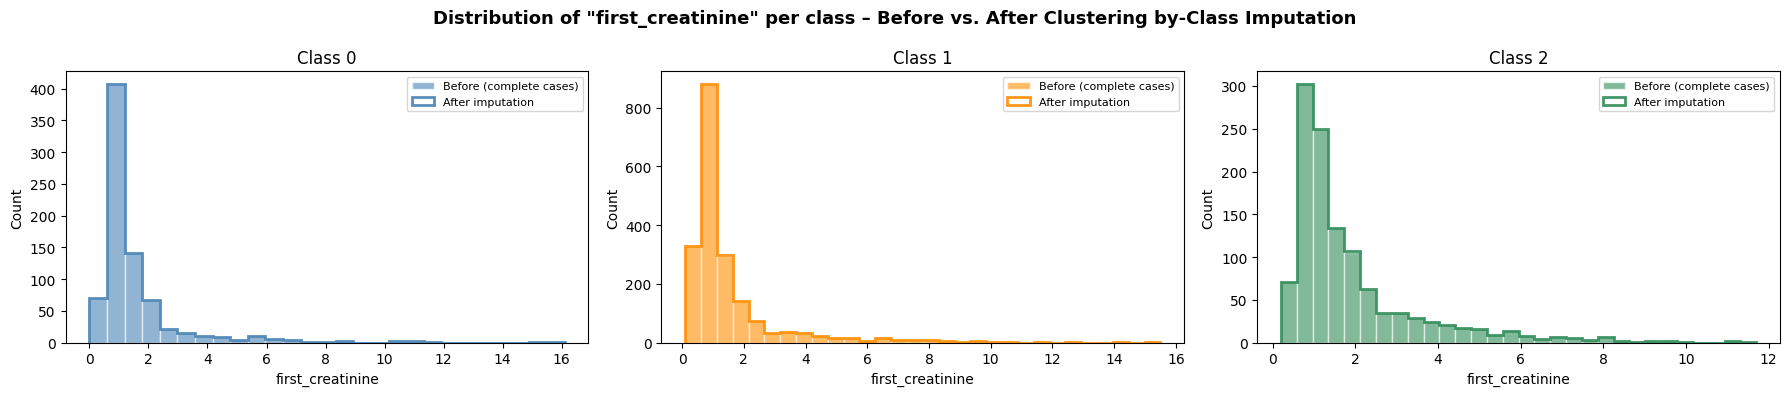

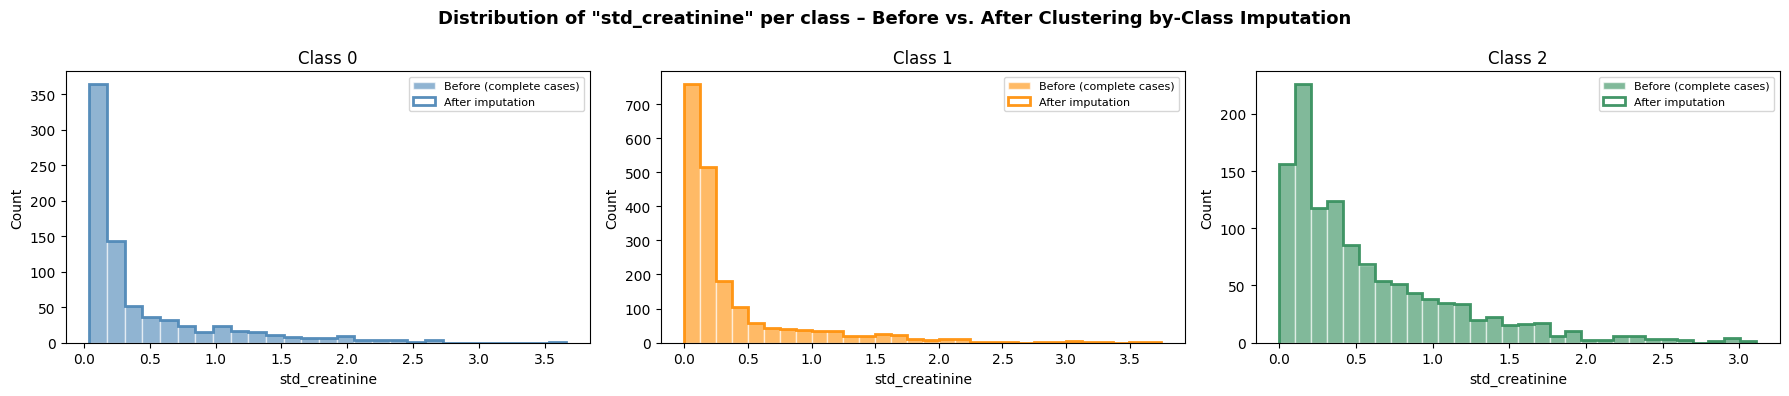

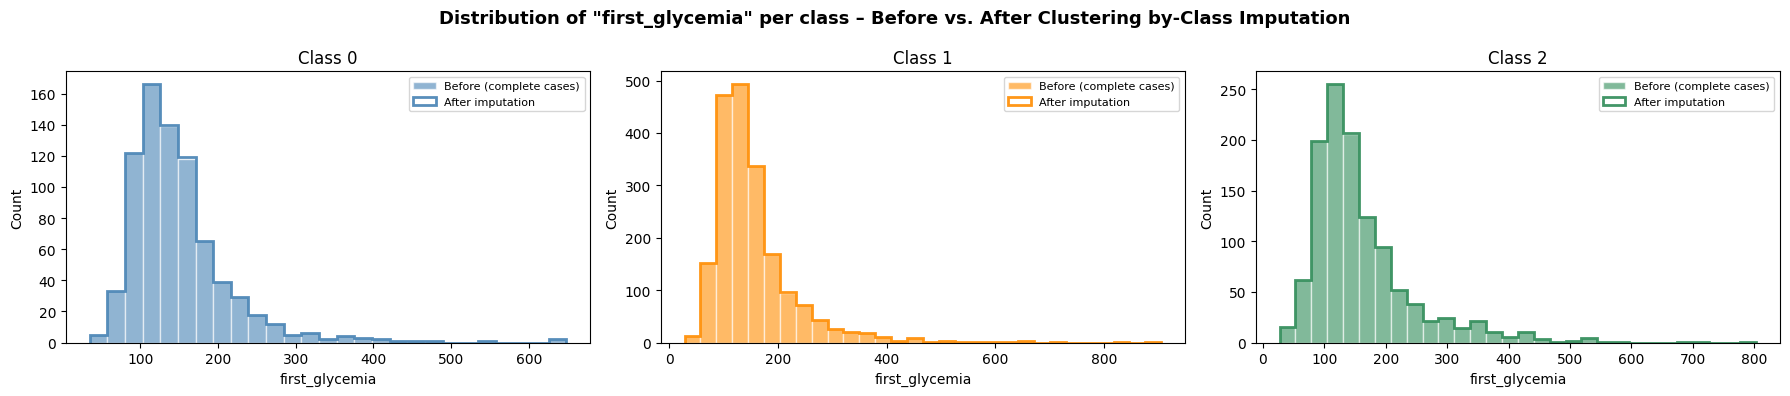

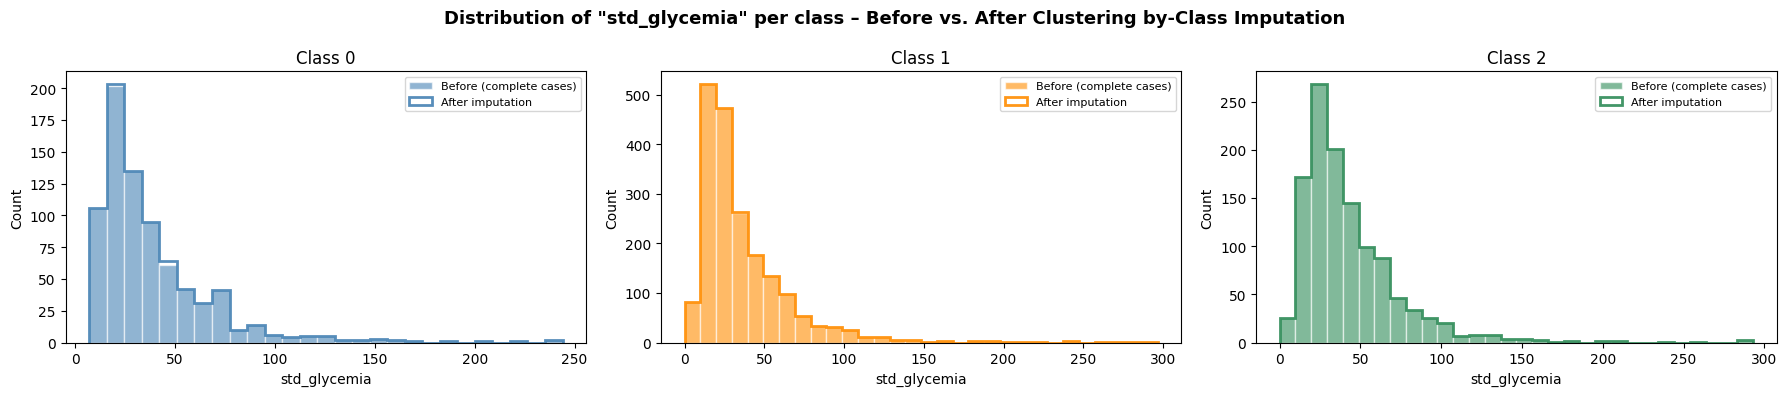

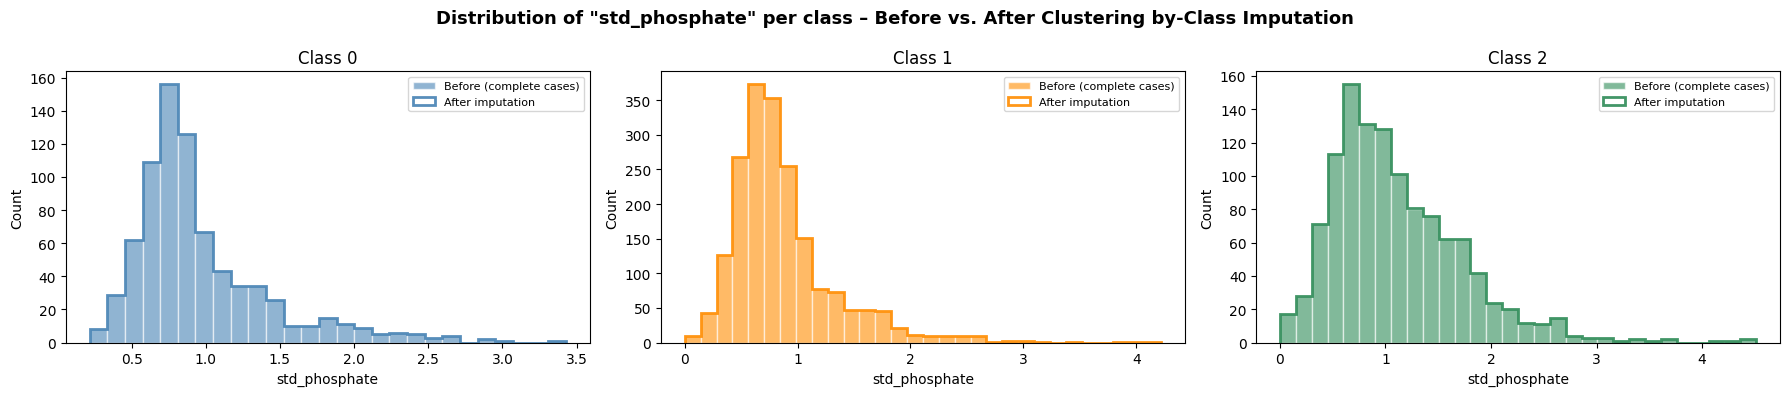

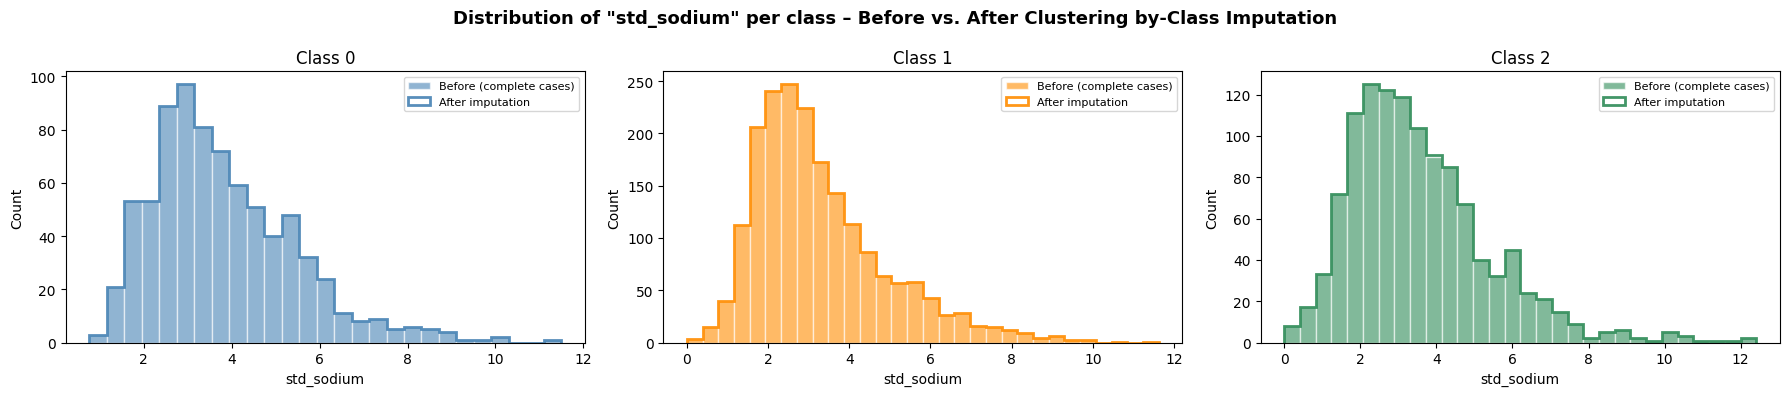

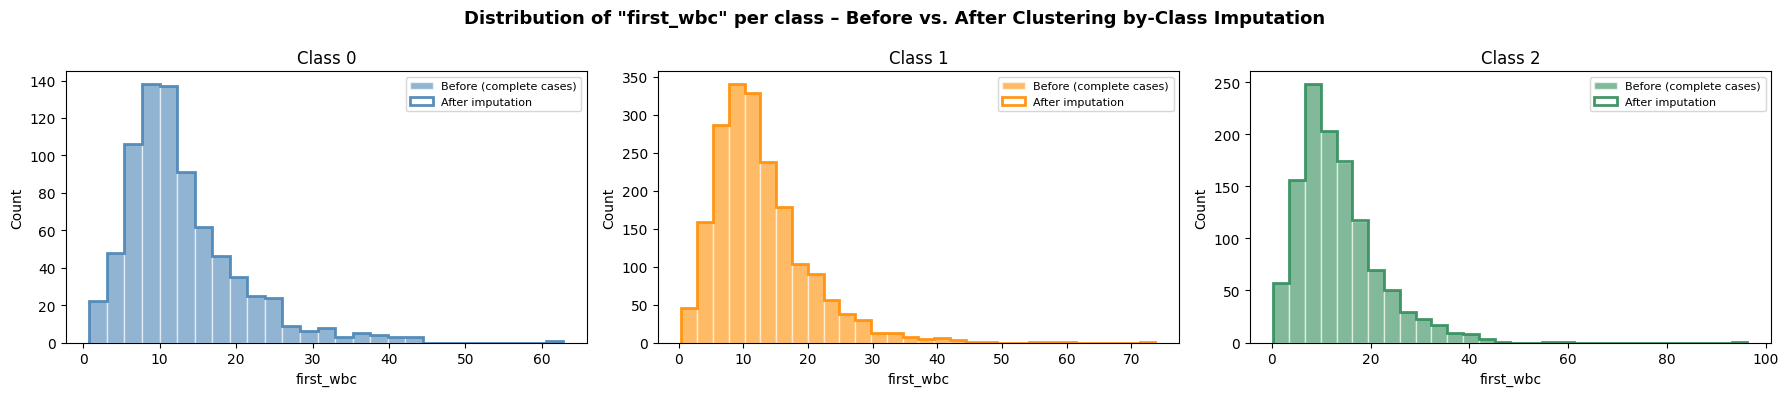

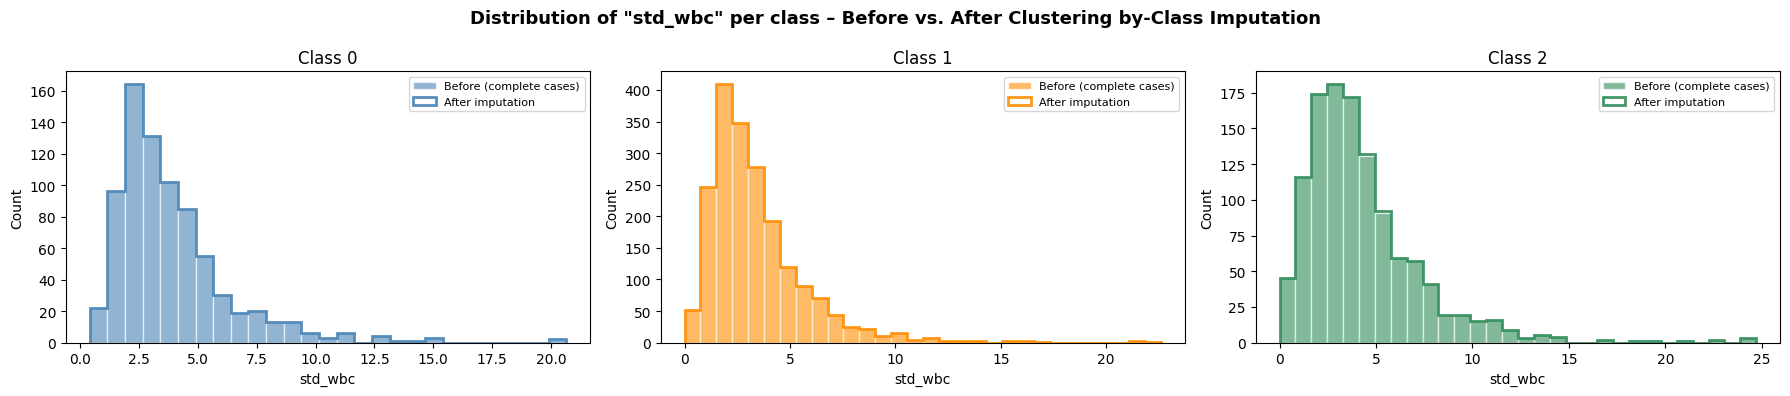

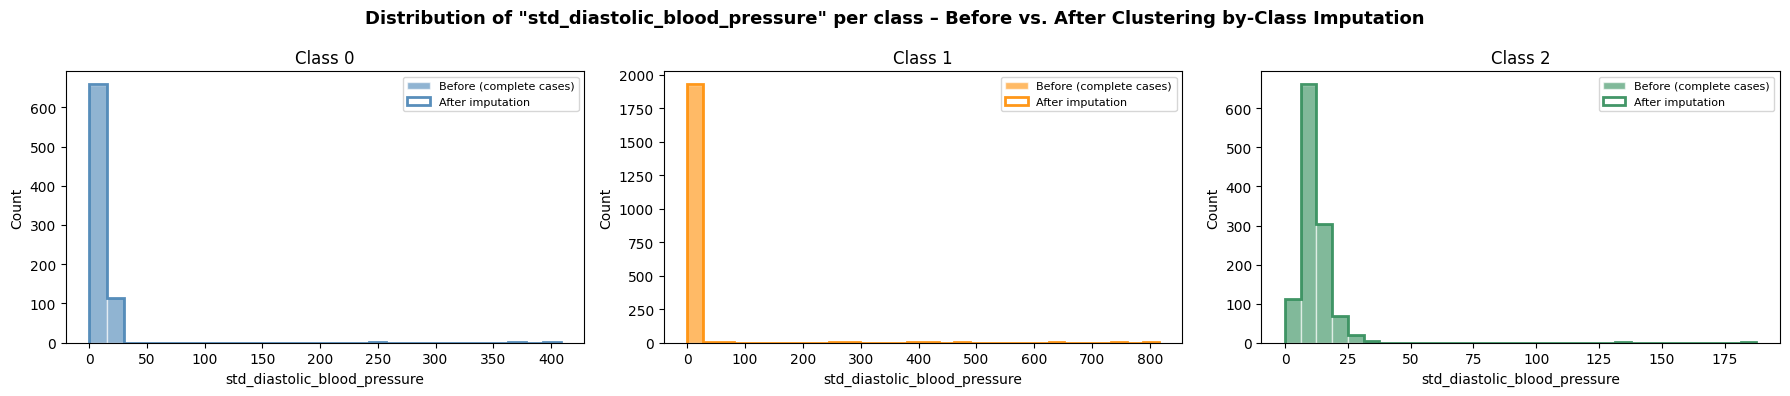

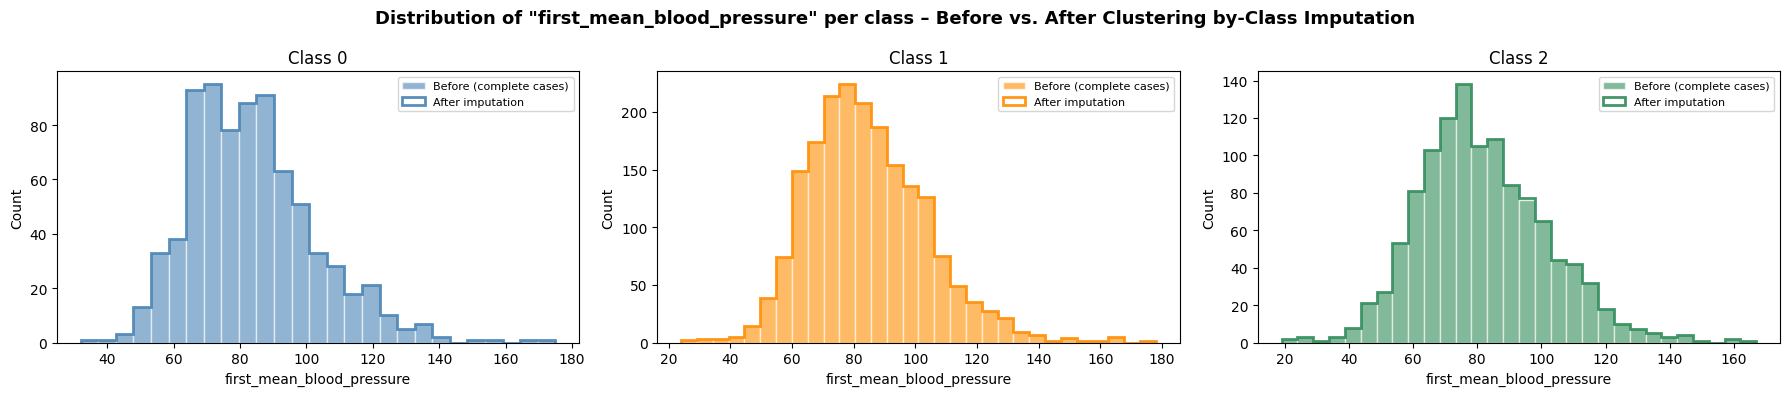

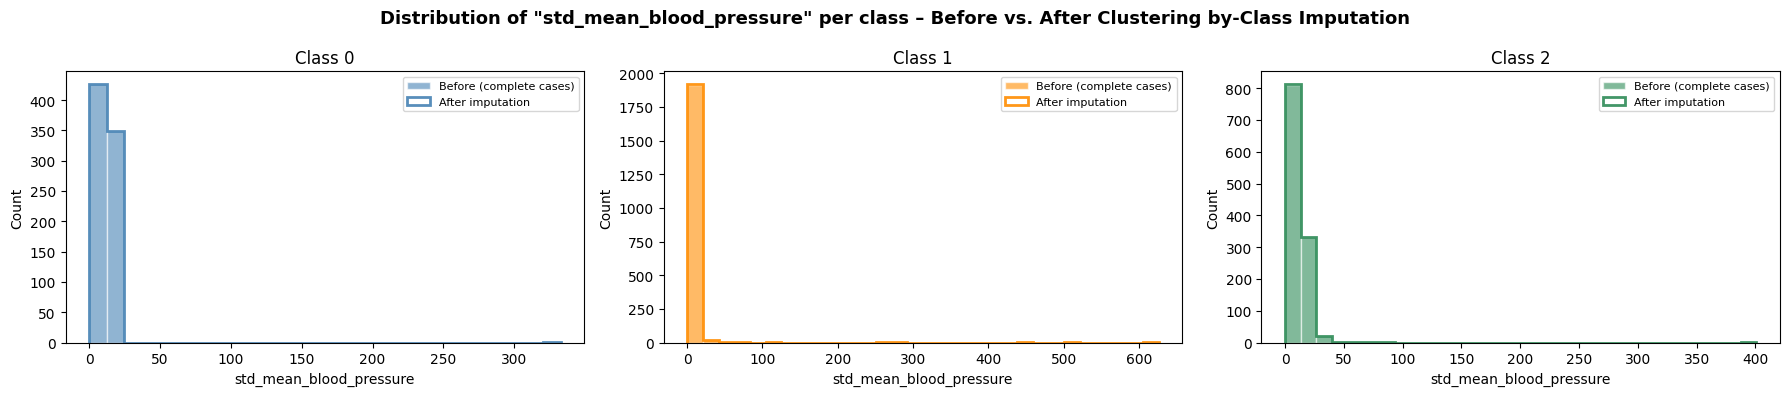

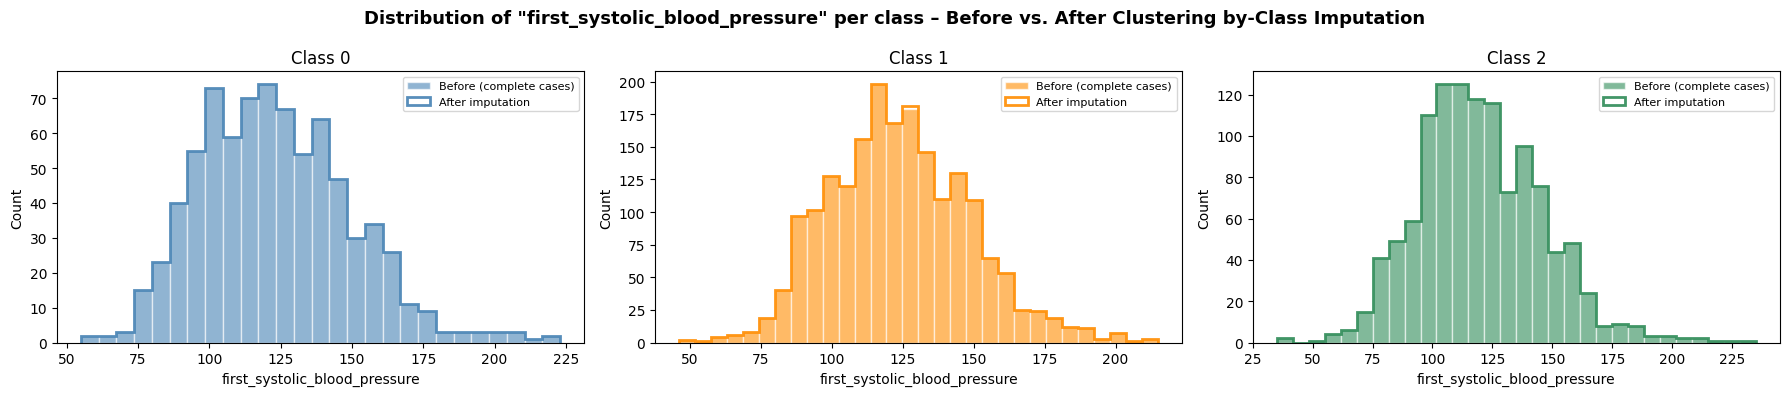

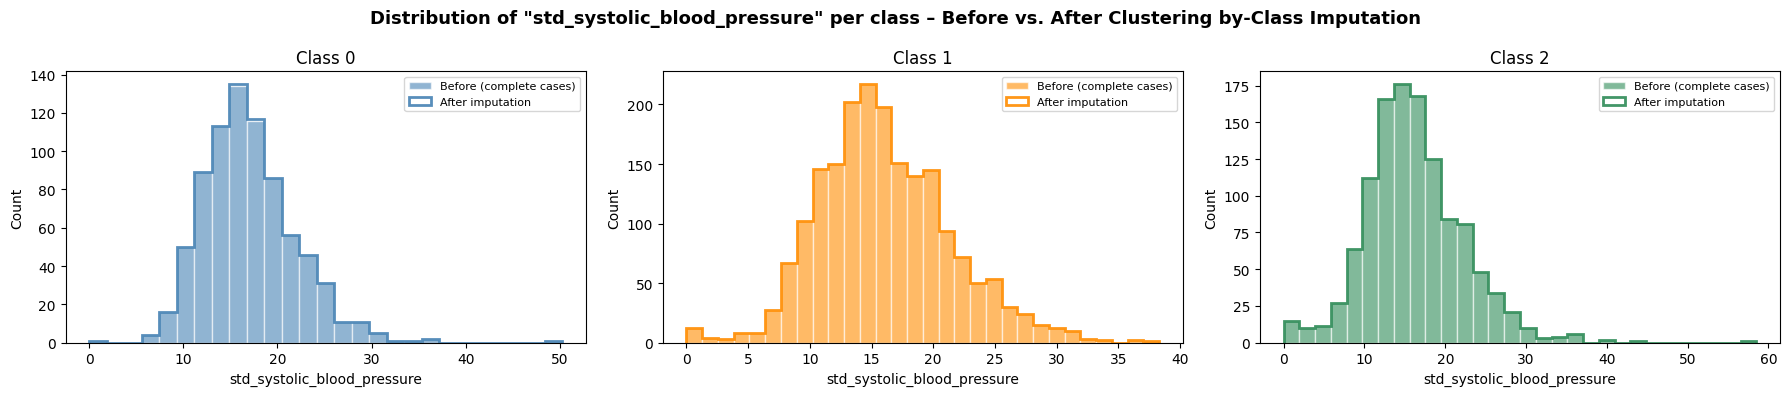

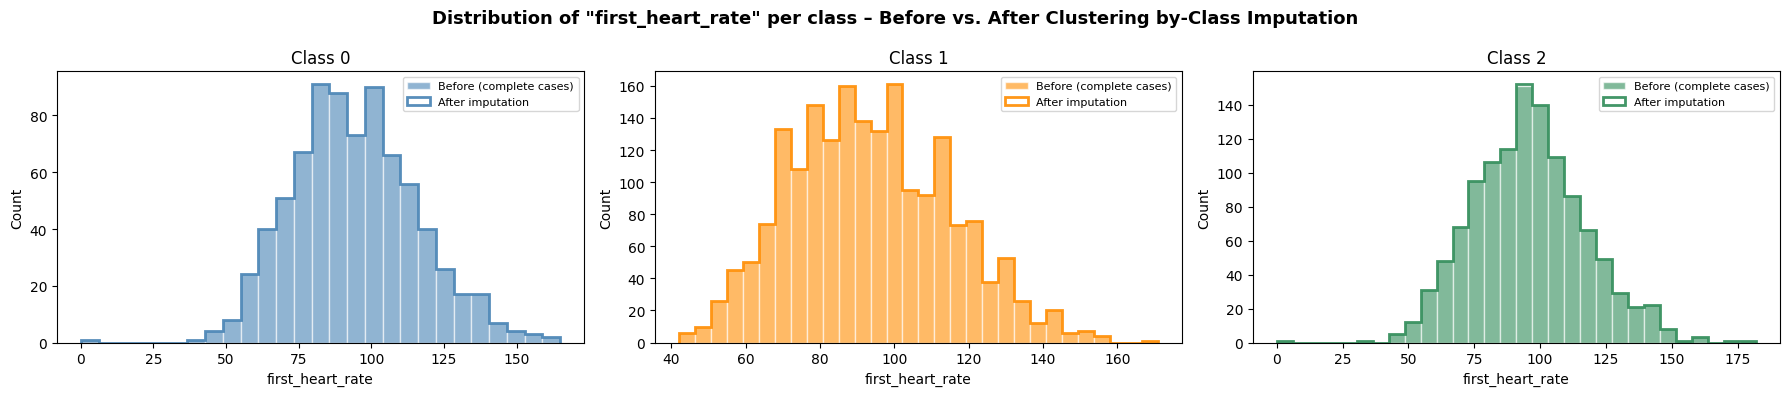

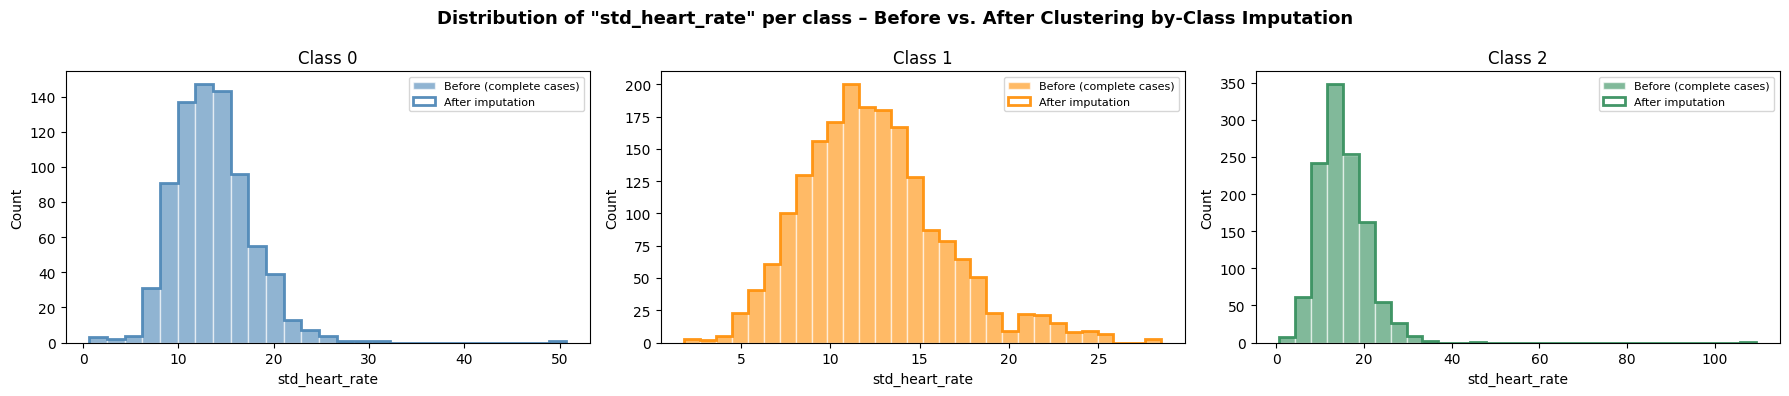

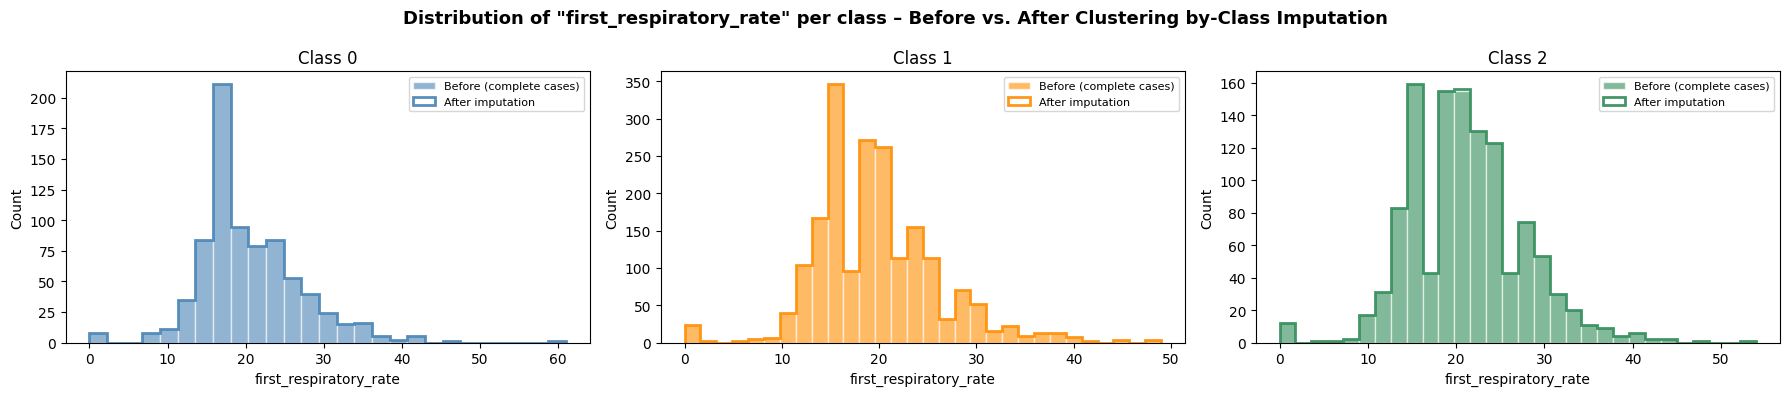

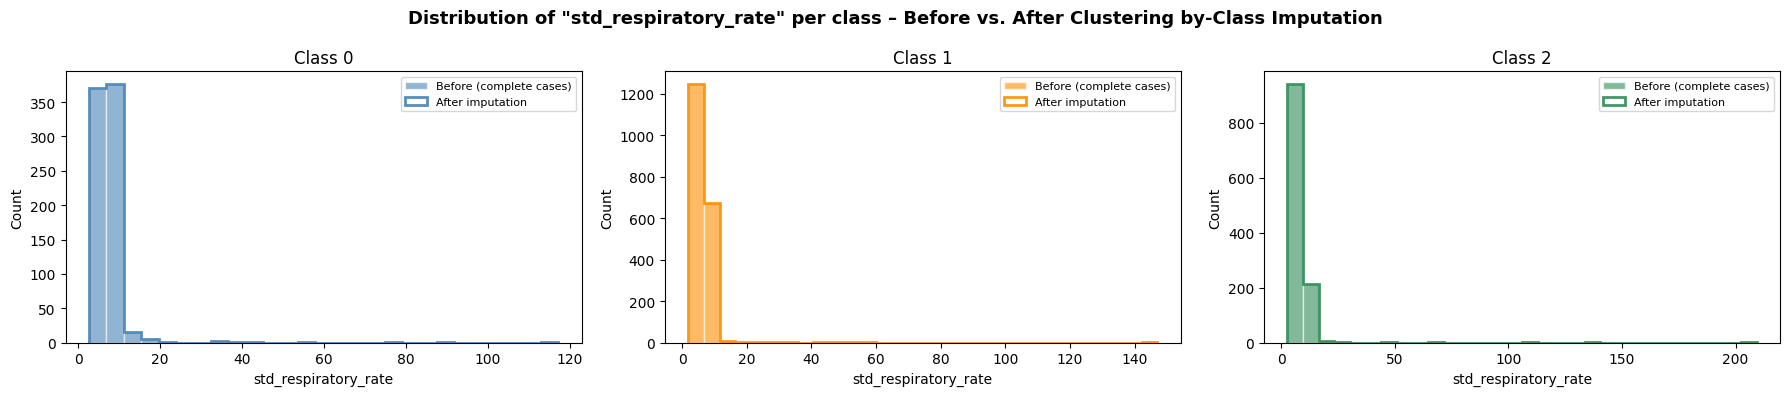

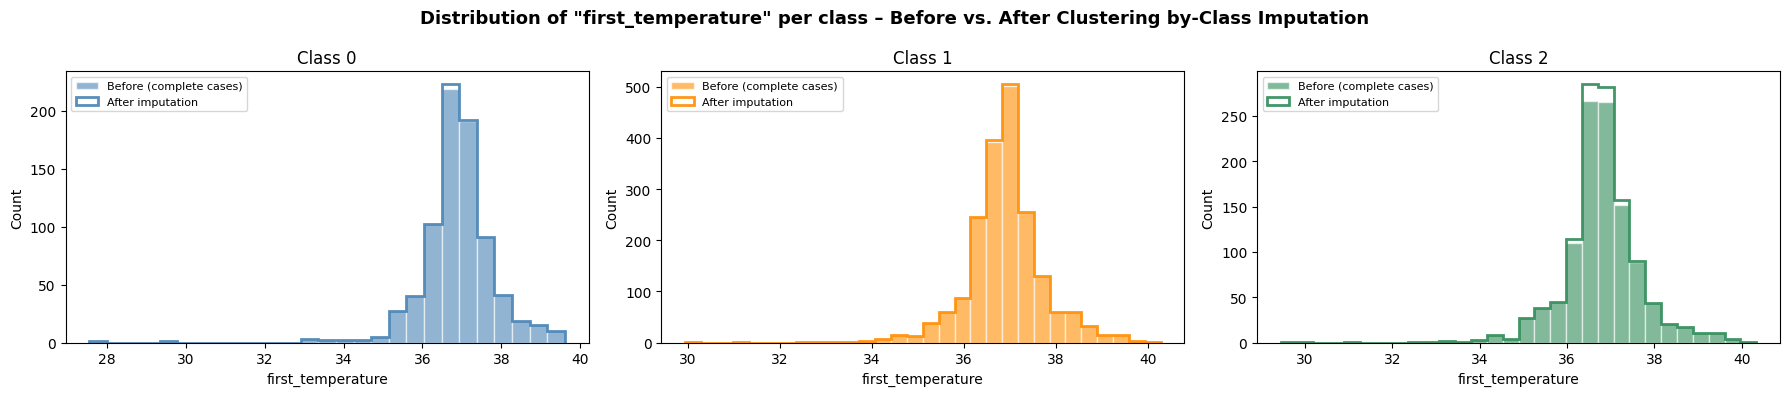

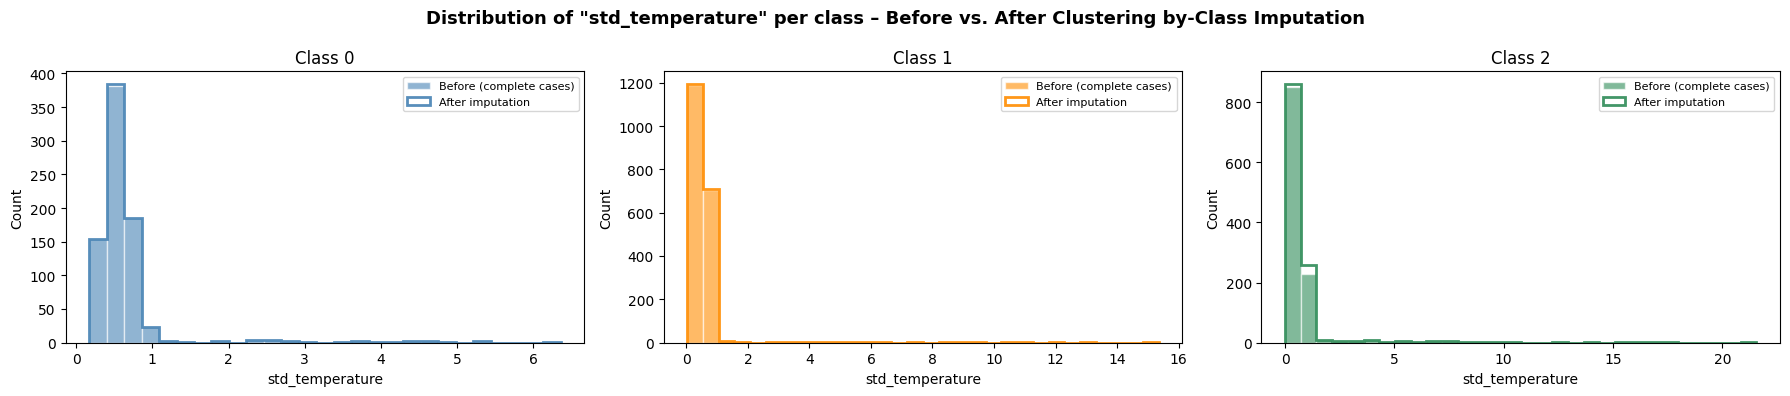

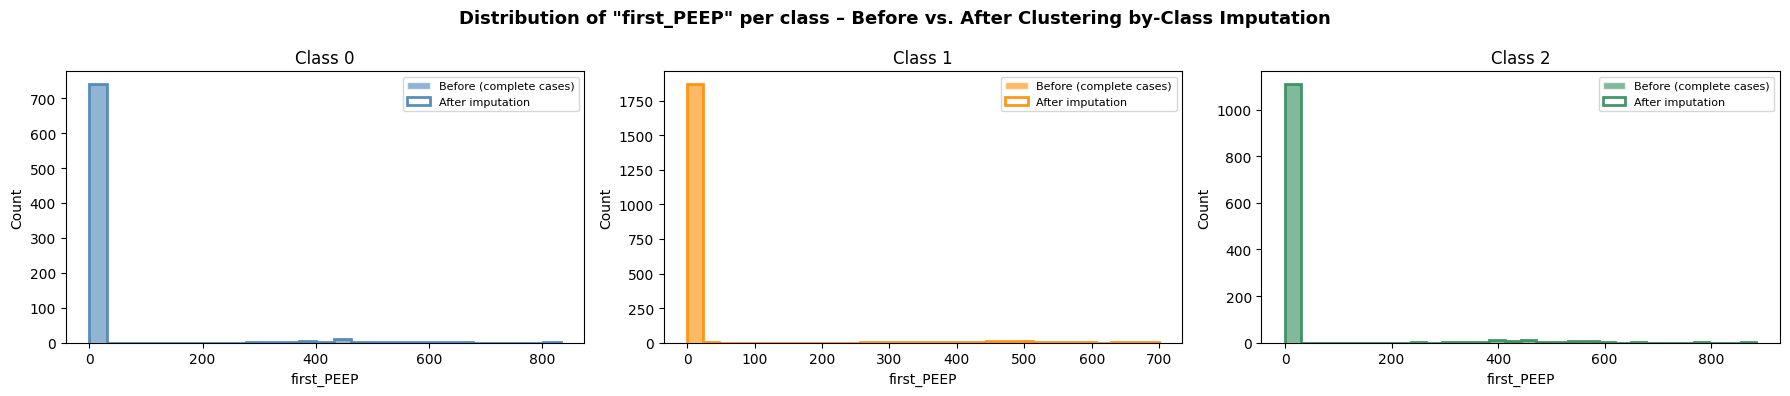

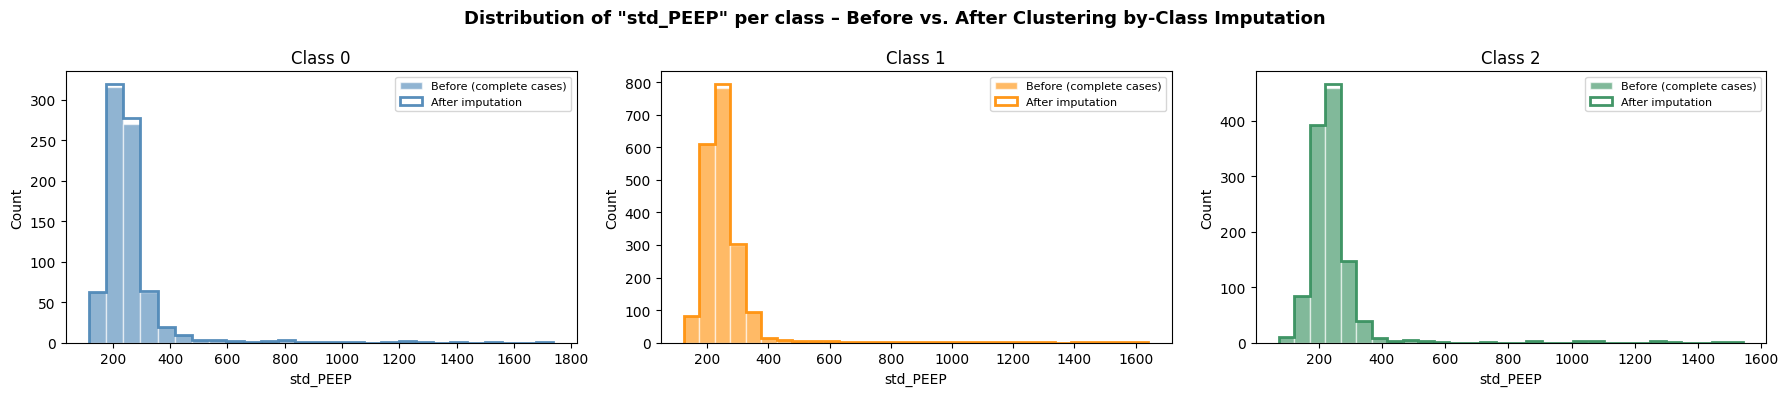

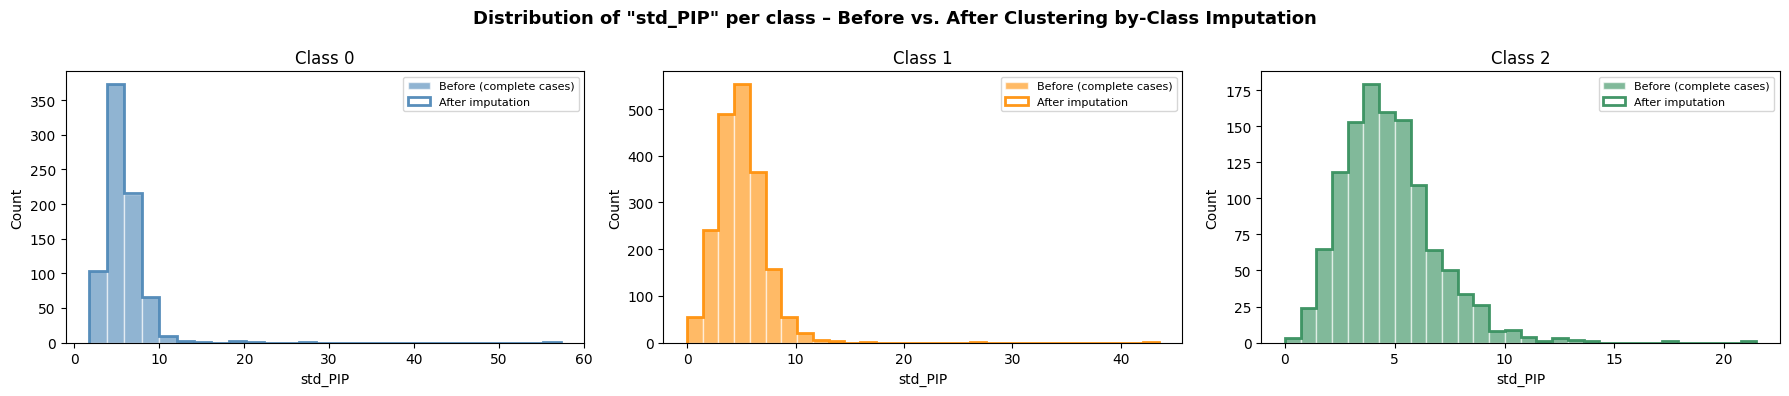

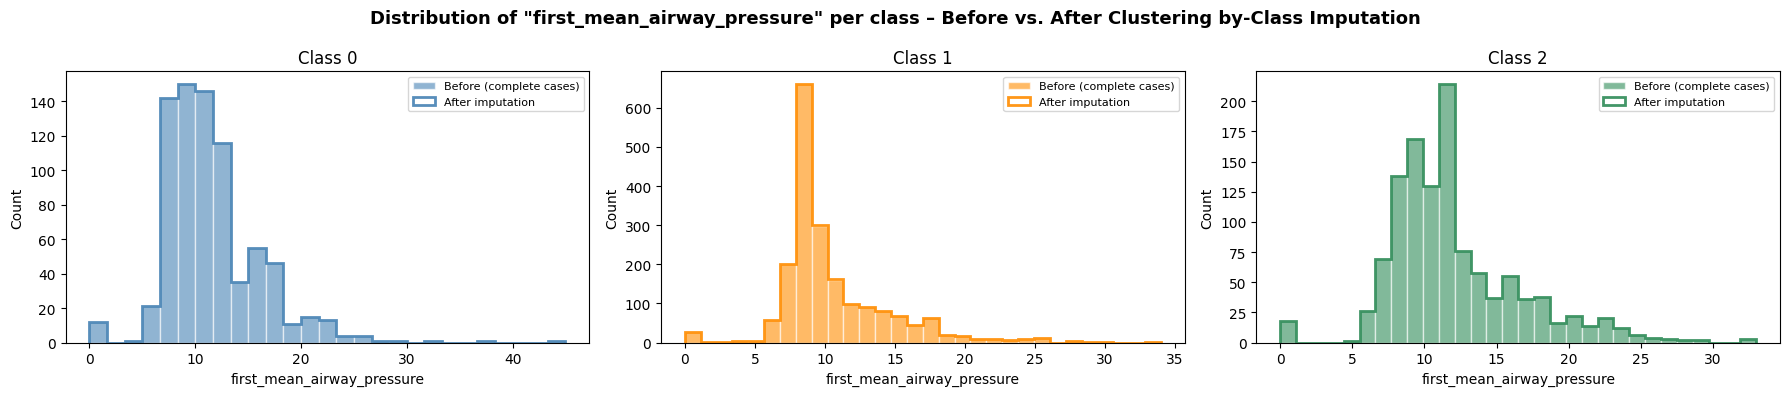

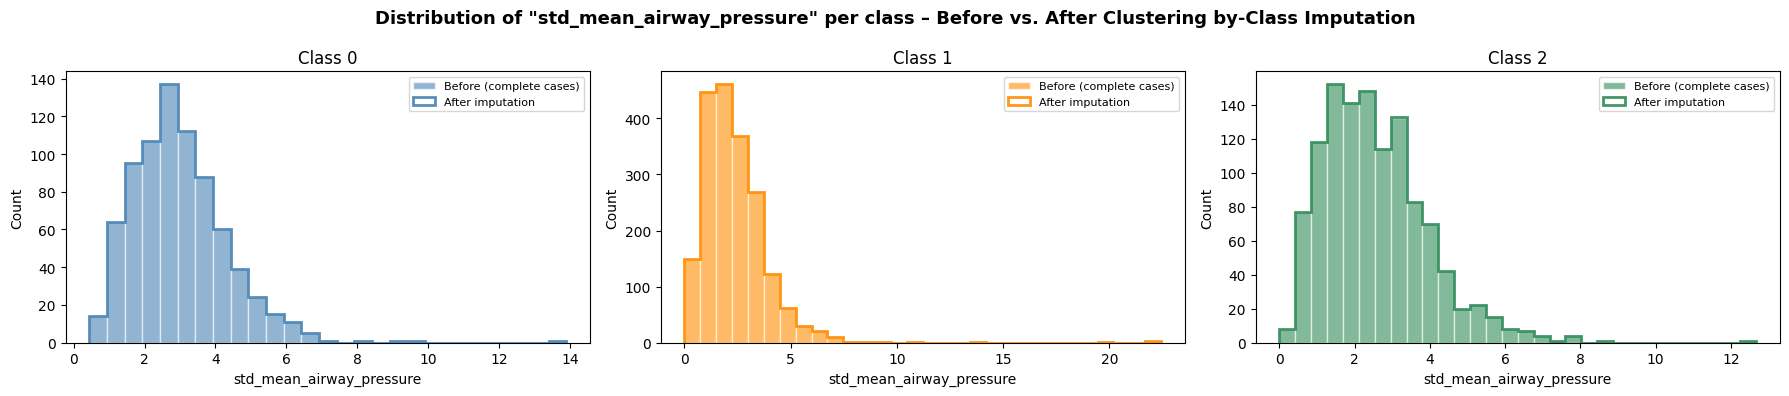

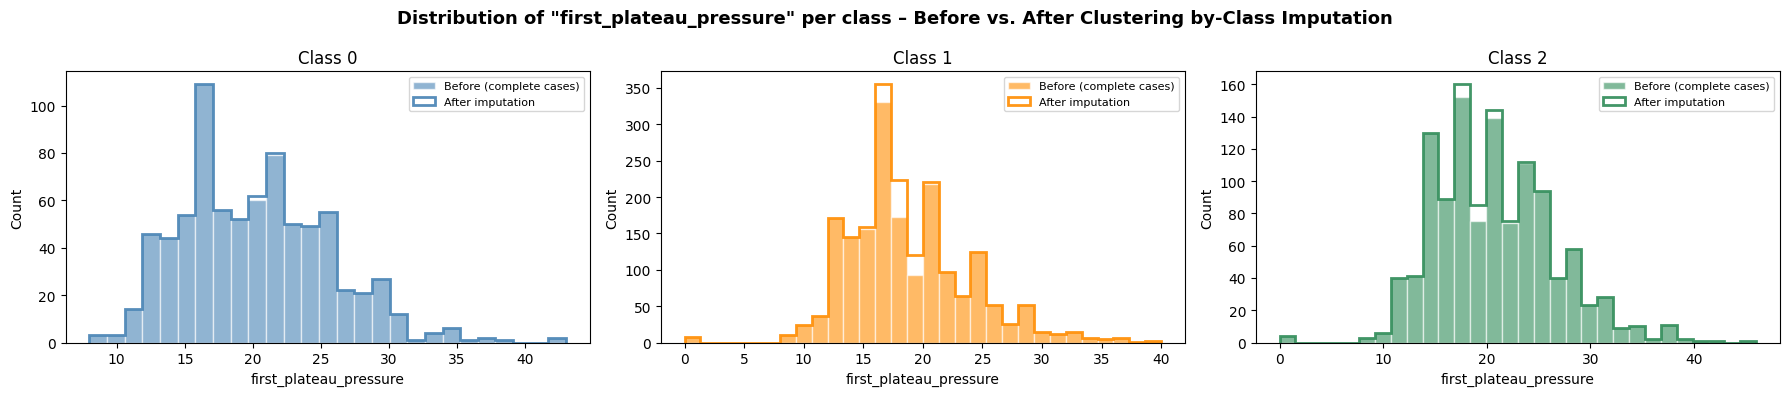

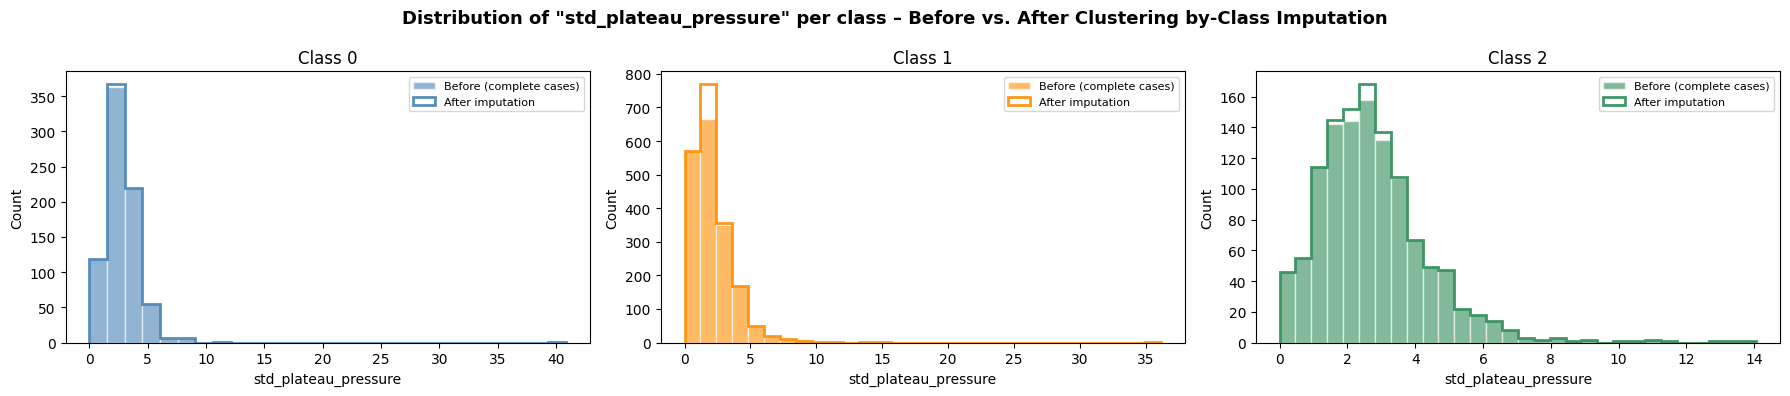

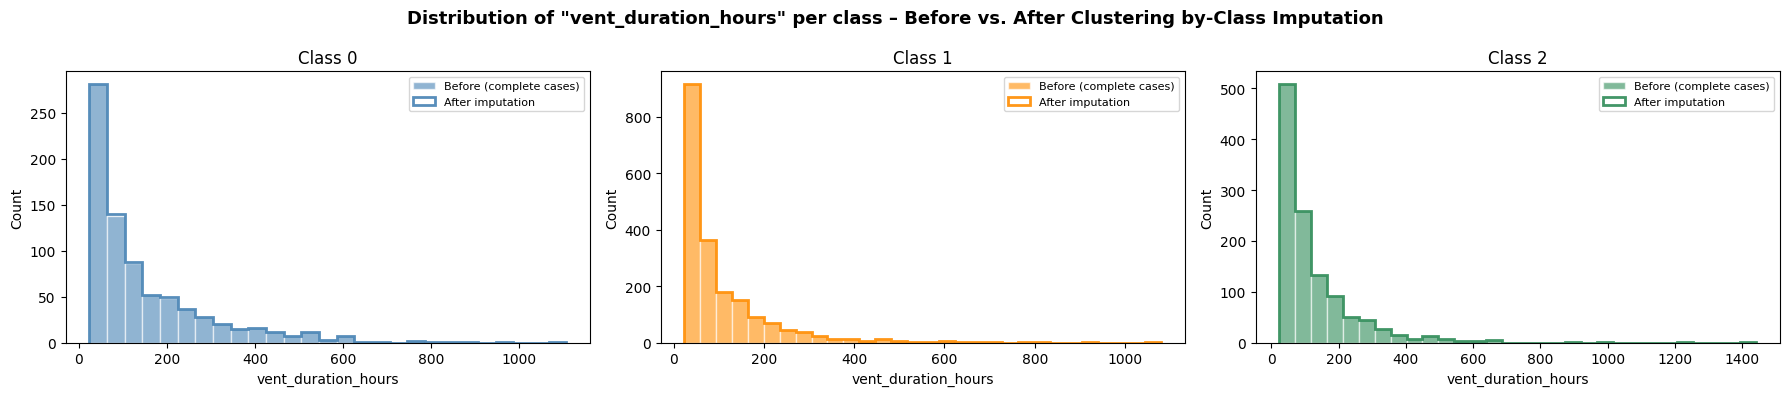

In [19]:
import matplotlib.pyplot as plt

# All variables that had at least one missing value
vars_with_mv = [col for col in input_features if df[col].isna().any()]

class_colors = {0: 'steelblue', 1: 'darkorange', 2: 'seagreen'}
class_labels = {0: 'Class 0', 1: 'Class 1', 2: 'Class 2'}

for col in vars_with_mv:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
    fig.suptitle(
        f'Distribution of "{col}" per class – Before vs. After Clustering by-Class Imputation',
        fontsize=13, fontweight='bold'
    )

    for ax, cls in zip(axes, [0, 1, 2]):
        mask   = df['outcome'] == cls
        before = df.loc[mask, col].dropna()                  # complete cases only
        after  = df_final_by_class.loc[mask, col].dropna()   # all (imputed included)

        bins = min(30, max(5, int(len(after) ** 0.5)))

        # Filled bars = before imputation
        ax.hist(before, bins=bins, alpha=0.6,
                color=class_colors[cls], label='Before (complete cases)',
                edgecolor='white')
        # Step line = after imputation (shows effect of added imputed values)
        ax.hist(after, bins=bins, alpha=0.9,
                color=class_colors[cls], label='After imputation',
                histtype='step', linewidth=2)

        ax.set_title(class_labels[cls])
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## Final saving

In [20]:
# Save the imputed dataset (clustering by class) into a new Excel sheet
new_sheet_name = "Dataset_step_3d"

with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_final_by_class.to_excel(writer, sheet_name=new_sheet_name, index=False)

print(f"Dataset saved to new sheet: '{new_sheet_name}' in '{file_path}'")

Dataset saved to new sheet: 'Dataset_step_3d' in 'Dataset_DAPPC_2026.xlsx'
